In [ ]:
import pandas as pd


# --- 1. CONFIGURAZIONE E CARICAMENTO ---
# Definiamo il percorso del file. Se il file è nella stessa cartella dello script, basta il nome.
file_path = 'data/train/training_data.csv'

print(f"Sto caricando il file da: {file_path}...")
df = pd.read_csv(file_path)
print("Caricamento completato!")

# --- 2. ORDINAMENTO TEMPORALE (CRUCIALE) ---
# I dati grezzi potrebbero non essere sequenziali. 
# Per fare prognostica, dobbiamo garantire che la riga N venga prima della riga N+1 nel tempo.
# Ordiniamo per:
# 1. ESN (Numero Motore): Per non mischiare i dati del motore 101 con il 102.
# 2. Cycles_Since_New (Età): Per mettere in fila i voli dal primo all'ultimo.
# 3. Snapshot (Istante): Per mettere in ordine gli scatti all'interno dello stesso volo.
df = df.sort_values(by=['ESN', 'Cycles_Since_New', 'Snapshot'])

# Resettiamo l'indice per avere una numerazione pulita delle righe (0, 1, 2...)
df = df.reset_index(drop=True)

# --- 3. ISPEZIONE DEI DATI ---
print("\n--- INFO GENERALE DATASET ---")
# .info() è utilissimo: ci dice quante righe totali abbiamo e il tipo di dati.
df.info()

print("\n--- ANTEPRIMA (PRIME 5 RIGHE) ---")
# Vediamo concretamente come sono fatti i dati
print(df.head())

# --- 4. CONTROLLO QUALITÀ DATI (MISSING VALUES) ---
print("\n--- CONTEGGIO VALORI MANCANTI (NaN) ---")
# Contiamo quanti dati mancano per ogni colonna.
# Se vedi numeri > 0 qui, dovrai gestire questi buchi nella fase di pulizia.
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0]) # Stampa solo le colonne che hanno problemi

Sto caricando il file da: data/train/training_data.csv...
Caricamento completato!

--- INFO GENERALE DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 59702 entries, 0 to 59701
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ESN                 59702 non-null  int64  
 1   Cycles_Since_New    59702 non-null  int64  
 2   Snapshot            59702 non-null  int64  
 3   Cumulative_WWs      59702 non-null  int64  
 4   Cumulative_HPC_SVs  59702 non-null  int64  
 5   Cumulative_HPT_SVs  59702 non-null  int64  
 6   Sensed_Altitude     59702 non-null  float64
 7   Sensed_Mach         59702 non-null  float64
 8   Sensed_Pamb         59702 non-null  float64
 9   Sensed_Pt2          59702 non-null  float64
 10  Sensed_TAT          59702 non-null  float64
 11  Sensed_WFuel        59005 non-null  float64
 12  Sensed_VAFN         59702 non-null  float64
 13  Sensed_VBV          59702 non-null  float64
 14  

In [2]:
#--
print("Analisi snapshot")

# Count ci dice quante righe (snapshot) ci sono per ogni volo
snapshot_counts = df.groupby(['ESN', 'Cycles_Since_New'])['Snapshot'].count()

# 2. Statistiche di base
max_snap = snapshot_counts.max()
min_snap = snapshot_counts.min()
print(f"Max snapshot per volo: {max_snap}")
print(f"Min snapshot per volo: {min_snap}")

# 3. Vediamo la distribuzione
# Ci dice: "Ci sono X voli con 8 snapshot, Y voli con 7 snapshot..."
print("\nDistribuzione frequenza snapshot:")
print(snapshot_counts.value_counts().sort_index())

# 4. Identificazione dei voli con "buchi" (Gaps)
# Esempio: ho snapshot 1, 2, 4 -> Manca il 3. Questo codice lo trova.
def has_gap(series):
    # Crea un set dei numeri attesi (dal minimo al massimo trovati in quel volo)
    expected = set(range(series.min(), series.max() + 1))
    actual = set(series)
    # Se la differenza tra i due set non è vuota, manca qualcosa
    return len(expected - actual) > 0

# Applichiamo la funzione a tutti i voli (può richiedere qualche secondo)
gaps = df.groupby(['ESN', 'Cycles_Since_New'])['Snapshot'].apply(has_gap)
num_gaps = gaps[gaps == True].count()

print(f"\nNumero di voli con sequenza snapshot interrotta (buchi): {num_gaps}")

if num_gaps > 0:
    print("Esempio di volo con buchi:")
    # Prendiamo il primo caso trovato
    example_idx = gaps[gaps == True].index[0] 
    print(f"Motore {example_idx[0]}, Volo {example_idx[1]}")
    print(df[(df['ESN'] == example_idx[0]) & (df['Cycles_Since_New'] == example_idx[1])][['Snapshot', 'Sensed_Altitude']])

Analisi snapshot
Max snapshot per volo: 8
Min snapshot per volo: 7

Distribuzione frequenza snapshot:
Snapshot
7    4330
8    3674
Name: count, dtype: int64

Numero di voli con sequenza snapshot interrotta (buchi): 4330
Esempio di volo con buchi:
Motore 101, Volo 0
   Snapshot  Sensed_Altitude
0         1       851.321516
1         2       903.321516
2         3      3410.321516
3         4     20259.321516
4         6     21991.321516
5         7     21997.321516
6         8     21996.321516


In [3]:
# STRATEGIA Crociera stabile ---
# Definiamo una soglia di altitudine per considerare l'aereo in "Crociera".
ALTITUDE_THRESHOLD = 20000 

print(f"Dataset originale: {df.shape} righe (snapshot singoli)")

# 2. Filtraggio: Teniamo solo i dati in quota
# Creiamo una maschera booleana: teniamo solo le righe dove l'altitudine è > 20000
cruise_mask = df['Sensed_Altitude'] > ALTITUDE_THRESHOLD
df_cruise = df[cruise_mask].copy()

print(f"Dataset filtrato (solo quota > {ALTITUDE_THRESHOLD}): {df_cruise.shape} righe")


# Dobbiamo comprimere i vari snapshot in una sola riga per volo.
# Ma non tutte le colonne si trattano allo stesso modo!

# A) COLONNE SENSORI
# Vogliamo la MEDIA (mean). Perché? Perché riduce il rumore di lettura dei sensori.
sensor_cols = [c for c in df.columns if 'Sensed_' in c]

# B) COLONNE TARGET  
# Queste non cambiano durante il volo. Se mancano 100 cicli all'inizio del volo, ne mancano 100 anche alla fine.
# Usiamo 'first' (prendi il primo valore che trovi).
target_cols = ['Cycles_to_WW', 'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']

# C) METADATI (Cumulative_...):
# Contatori cumulativi. Usiamo 'max' per sicurezza (prendiamo il valore più alto registrato nel volo).
meta_cols = ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']

# Creiamo il dizionario che dice a Pandas cosa fare per ogni colonna
agg_dict = {}
for col in sensor_cols:
    agg_dict[col] = 'mean'
for col in target_cols:
    agg_dict[col] = 'first'
for col in meta_cols:
    agg_dict[col] = 'max'

# 4. Aggregazione (Il cuore della strategia)
# Raggruppiamo per 'ESN' (Motore) e 'Cycles_Since_New' (Età/Volo)
# Questo comando schiaccia tutte le righe dello stesso volo in una sola, applicando le regole sopra.
df_grouped = df_cruise.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()

# 5. Risultato Finale
print(f"Dataset finale aggregato: {df_grouped.shape} righe (una per volo)")

# Salviamo il file pulito per usarlo nei prossimi passaggi
df_grouped.to_csv('training_data_cleaned.csv', index=False)
print("File 'training_data_cleaned.csv' salvato con successo.")

Dataset originale: (59702, 25) righe (snapshot singoli)
Dataset filtrato (solo quota > 20000): (36253, 25) righe
Dataset finale aggregato: (7845, 24) righe (una per volo)
File 'training_data_cleaned.csv' salvato con successo.


In [4]:
# 4. Stampa Output
# Usiamo to_string() per forzare Python a stampare tutte le colonne senza tagliarle
print("--- ANTEPRIMA TABELLA AGGREGATA (15 righe) ---")
print(df_grouped.head(15).to_string())

print("\nESEMPIO MOTORE ESN 102")
print(df_grouped[df_grouped['ESN'] == 102].head(5).to_string())

--- ANTEPRIMA TABELLA AGGREGATA (15 righe) ---
    ESN  Cycles_Since_New  Sensed_Altitude  Sensed_Mach  Sensed_Pamb  Sensed_Pt2  Sensed_TAT  Sensed_WFuel  Sensed_VAFN  Sensed_VBV  Sensed_Fan_Speed  Sensed_Core_Speed  Sensed_T25    Sensed_T3  Sensed_Ps3   Sensed_T45  Sensed_P25    Sensed_T5  Cycles_to_WW  Cycles_to_HPC_SV  Cycles_to_HPT_SV  Cumulative_WWs  Cumulative_HPC_SVs  Cumulative_HPT_SVs
0   101                 0     21561.071516     0.624281     6.342453    8.222654  495.289555      0.554608  4484.591786    0.009658       1732.762805       19978.130319  683.653541  1440.268613  238.846836  1910.568924   22.419295  1215.706083           910              8510              4090               0                   0                   0
1   101                10     24517.821516     0.663877     5.607710    7.495710  497.792314      0.574313  4518.625303    0.000000       1833.229898       20334.107114  703.055003  1488.234013  239.539026  1993.571117   22.035035  1242.192320          

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [6]:
def process_dataset(df):
    """
    Trasforma il dataset grezzo in uno pulito (Cruise Only).
    Si adatta dinamicamente alle colonne presenti.
    """
    print(f"   -> Processing {df.shape[0]} righe grezze...")
    
    # 1. Filtro Altitudine (Solo se la colonna esiste)
    if 'Sensed_Altitude' in df.columns:
        ALTITUDE_THRESHOLD = 20000 
        cruise_mask = df['Sensed_Altitude'] > ALTITUDE_THRESHOLD
        df_cruise = df[cruise_mask].copy()
    else:
        df_cruise = df.copy() # Se manca l'altitudine, usiamo tutto
    
    # 2. Definizione Regole di Aggregazione DINAMICA
    # Cerchiamo le colonne che ESISTONO DAVVERO nel dataframe attuale
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    
    potential_meta = ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
    meta_cols = [c for c in potential_meta if c in df.columns] # <--- FIX CRUCIALE
    
    potential_targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_WW']
    target_cols = [c for c in potential_targets if c in df.columns] # <--- FIX CRUCIALE

    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    for col in meta_cols: agg_dict[col] = 'max'
    for col in target_cols: agg_dict[col] = 'first'
    
    # 3. Aggregazione
    # Verifica che le chiavi di raggruppamento esistano
    if 'ESN' in df_cruise.columns and 'Cycles_Since_New' in df_cruise.columns:
        df_grouped = df_cruise.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        print(f"   -> Risultato: {df_grouped.shape[0]} voli (righe) pronti.")
        return df_grouped
    else:
        print("ERRORE: Colonne ESN o Cycles_Since_New mancanti.")
        return pd.DataFrame()

In [7]:
# ==============================================================================
# 2. FUNZIONI DI SCORING (METRICA UFFICIALE PHM)
# ==============================================================================


def time_weighted_error(y_true, y_pred, alpha=0.02, beta=1):
    """Calcola l'errore pesato asimmetrico per singola predizione."""
    error = y_pred - y_true
    # Se error >= 0 (Predizione Tardiva/Late): Penalità doppia
    # Se error < 0 (Predizione Anticipata/Early): Penalità standard
    weight = np.where(
        error >= 0,
        2 / (1 + alpha * y_true),
        1 / (1 + alpha * y_true)
    )
    return weight * (error ** 2) * beta

def get_official_score(y_true, y_pred, component_type):
    """Calcola lo score medio in base al componente (HPT, HPC, WW)."""
    alpha = 0.01  # Fisso da regolamento
    
    # Il Beta cambia in base al massimo ciclo teorico del componente
    max_val = np.max(y_true)
    if max_val == 0: max_val = 1 # Evita divisione per zero
    
    if component_type == 'WW':
        beta = 1 / float(max_val)
    else:
        # HPT e HPC hanno beta pesato x2
        beta = 2 / float(max_val)
        
    scores = time_weighted_error(y_true, y_pred, alpha, beta)
    return np.mean(scores)

# ==============================================================================
# 3. MAIN SCRIPT
# ==============================================================================
def main():
    # --- A. CARICAMENTO DATI ---
    print("caricamento dati di training")
    try:
        df_train_raw = pd.read_csv('data/train/training_data.csv')
        
        print("File di training caricati con successo.")
    except FileNotFoundError as e:
        print(f"ERRORE: Non trovo i file. Assicurati che training_data.csv e validation_data.csv siano nella cartella.\n{e}")
        return
    
    print("caricamento dati di validation")
    path_validation = "data/val/*.csv" 

    # Trova tutti i file che corrispondono al pattern
    all_files = glob.glob(path_validation)

    if len(all_files) == 0:
        print(f"ERRORE: Non ho trovato nessun file csv nel percorso: {path_validation}")
        exit()

    print(f"Trovati {len(all_files)} file di validazione. Unione in corso...")

    # Legge ogni file e lo aggiunge a una lista
    li = []
    for filename in all_files:
        df = pd.read_csv(filename, index_col=None, header=0)
        li.append(df)

    # Unisce tutto in un unico DataFrame
    df_val_raw = pd.concat(li, axis=0, ignore_index=True)

    print(f"Validation set unito caricato: {df_val_raw.shape} righe.")

    # --- C. FIX NOMI COLONNE (CRUCIALE) ---
    # Rinominiamo la colonna 'Cycles' in 'Cycles_Since_New' nel validation set
    if 'Cycles' in df_val_raw.columns and 'Cycles_Since_New' not in df_val_raw.columns:
        print("\n[FIX] Rinomino colonna 'Cycles' -> 'Cycles_Since_New' nel Validation Set...")
        df_val_raw.rename(columns={'Cycles': 'Cycles_Since_New'}, inplace=True)
    
    
    # --- B. PREPROCESSING ---
    print("\n--- 2. PREPROCESSING (CRUISE ONLY) ---")
    print("Processando Training Set:")
    df_train = process_dataset(df_train_raw)
    
    print("Processando Validation Set:")
    df_val = process_dataset(df_val_raw)

    if df_val.empty: return

    # --- C. PREPARAZIONE FEATURES (X) E TARGET (Y) ---
    
    # Usiamo SOLO le feature presenti in entrambi i dataset
    train_cols = set(df_train.columns)
    val_cols = set(df_val.columns)

    # Cerchiamo colonne che iniziano con Sensed_ o Cumulative_ che siano in ENTRAMBI
    potential_features = [c for c in train_cols if 'Sensed_' in c or 'Cumulative_' in c]
    features = [c for c in potential_features if c in val_cols]
    
    print(f"\nFeature selezionate ({len(features)}):")
    print(features)
    
    if len(features) == 0:
        print("ERRORE CRITICO: Non ci sono feature in comune tra Training e Validation!")
        return

    # --- F. ADDESTRAMENTO E PREDIZIONE ---
    X_train = df_train[features]
    X_val = df_val[features]
    
    # Target da predire (quelli presenti nel training)
    targets_train = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    targets_train = [t for t in targets_train if t in df_train.columns]
    
    # DataFrame per salvare i risultati
    results_df = df_val[['ESN', 'Cycles_Since_New']].copy()
    
    print("\n--- 4. ADDESTRAMENTO MODELLI ---")
    
    # [AGGIUNTA] Dizionario per salvare i dati per i grafici
    results = {} 

    for target in targets_train:
        print(f"Training su: {target} ...")
        
        # ... (il tuo codice di training e fit rimane uguale) ...
        model = RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)
        model.fit(X_train, df_train[target])
        
        # Predizione
        y_pred = model.predict(X_val)
        results_df[target] = y_pred 
        
        # --- MODIFICA QUI SOTTO ---
        # Valutazione e Salvataggio dati per Grafico
        if target in df_val.columns:
            y_true = df_val[target]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            
            # Calcolo score (se serve per il titolo del grafico)
            comp_type = 'HPT' if 'HPT' in target else ('WW' if 'WW' in target else 'HPC')
            score = get_official_score(y_true.values, y_pred, comp_type)
            
            print(f"   -> Validation RMSE: {rmse:.2f} | Score: {score:.4f}")
            
            # [AGGIUNTA] Salviamo nel dizionario per i grafici dopo
            results[target] = {'true': y_true, 'pred': y_pred, 'rmse': rmse, 'score': score}
        else:
            print(f"   -> Target mancante in validation. Errore non calcolabile.")

# --- G. SALVATAGGIO CSV ---
    print("\n--- 5. SALVATAGGIO ---")
    output_filename = 'submission_predictions.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"Predizioni salvate in: {output_filename}")

    # --- H. GENERAZIONE GRAFICI ---
    # Questo blocco parte solo se abbiamo trovato dei target nel validation set
    if results:
        print("\n--- 6. GENERAZIONE GRAFICI ---")
        n_plots = len(results)
        # Creiamo una figura con tanti sottografici quanti sono i target trovati
        fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
        
        # Se c'è un solo grafico, normalizziamo axes in una lista
        if n_plots == 1: axes = [axes]
        
        for i, (target_name, res) in enumerate(results.items()):
            ax = axes[i]
            
            # Scatter plot: Reale vs Predetto
            ax.scatter(res['true'], res['pred'], alpha=0.5, label='Predizioni')
            
            # Linea Ideale (y=x)
            min_val = min(res['true'].min(), res['pred'].min())
            max_val = max(res['true'].max(), res['pred'].max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideale')
            
            # Titoli e label
            label_clean = target_name.replace('Cycles_to_', '')
            ax.set_title(f"{label_clean}\nRMSE: {res['rmse']:.0f} | Score: {res['score']:.2f}")
            ax.set_xlabel('Reale (Cicli Rimanenti)')
            ax.set_ylabel('Predetto (Cicli Rimanenti)')
            ax.legend()
            ax.grid(True)
            
        plt.tight_layout()
        plt.savefig('validation_report.png')
        print("Grafico salvato come 'validation_report.png'")
        plt.show() # Mostra il grafico a video
    else:
        print("\nNessun grafico generato (Il validation set non aveva le etichette reali).")

    print("Processo completato.")
    
if __name__ == "__main__":
    main()

    

caricamento dati di training
File di training caricati con successo.
caricamento dati di validation
Trovati 48 file di validazione. Unione in corso...
Validation set unito caricato: (55910, 17) righe.

[FIX] Rinomino colonna 'Cycles' -> 'Cycles_Since_New' nel Validation Set...

--- 2. PREPROCESSING (CRUISE ONLY) ---
Processando Training Set:
   -> Processing 59702 righe grezze...
   -> Risultato: 7845 voli (righe) pronti.
Processando Validation Set:
   -> Processing 55910 righe grezze...
   -> Risultato: 604 voli (righe) pronti.

Feature selezionate (14):
['Sensed_Mach', 'Sensed_T25', 'Sensed_Core_Speed', 'Sensed_T45', 'Sensed_TAT', 'Sensed_WFuel', 'Sensed_Pamb', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Ps3', 'Sensed_Pt2', 'Sensed_Fan_Speed', 'Sensed_T3', 'Sensed_Altitude']

--- 4. ADDESTRAMENTO MODELLI ---
Training su: Cycles_to_HPT_SV ...
   -> Target mancante in validation. Errore non calcolabile.
Training su: Cycles_to_HPC_SV ...
   -> Target mancante in validation. Errore non calcolab

--- 1. CARICAMENTO DATI ---
Dataset completo caricato: (59702, 25) righe
Motori disponibili: [101 102 103 104]

--- CONFIGURAZIONE SPLIT ---
TRAINING su motori: [101 102 103]
VALIDATION (Test) su motore: 104
(Uso questo motore per calcolare l'errore perché di lui ho le risposte!)

--- 2. PREPROCESSING ---

--- 3. ADDESTRAMENTO E RISULTATI ---

Analisi Target: Cycles_to_HPT_SV
   -> RMSE (Errore Medio): 702.83 cicli
   -> SCORE PHM (Punteggio Gara): 70.2775

Analisi Target: Cycles_to_HPC_SV
   -> RMSE (Errore Medio): 1897.15 cicli
   -> SCORE PHM (Punteggio Gara): 15.6672

Analisi Target: Cycles_to_WW
   -> RMSE (Errore Medio): 282.30 cicli
   -> SCORE PHM (Punteggio Gara): 54.3143

--- 4. GENERAZIONE GRAFICI ---
Grafico salvato come 'error_analysis.png'


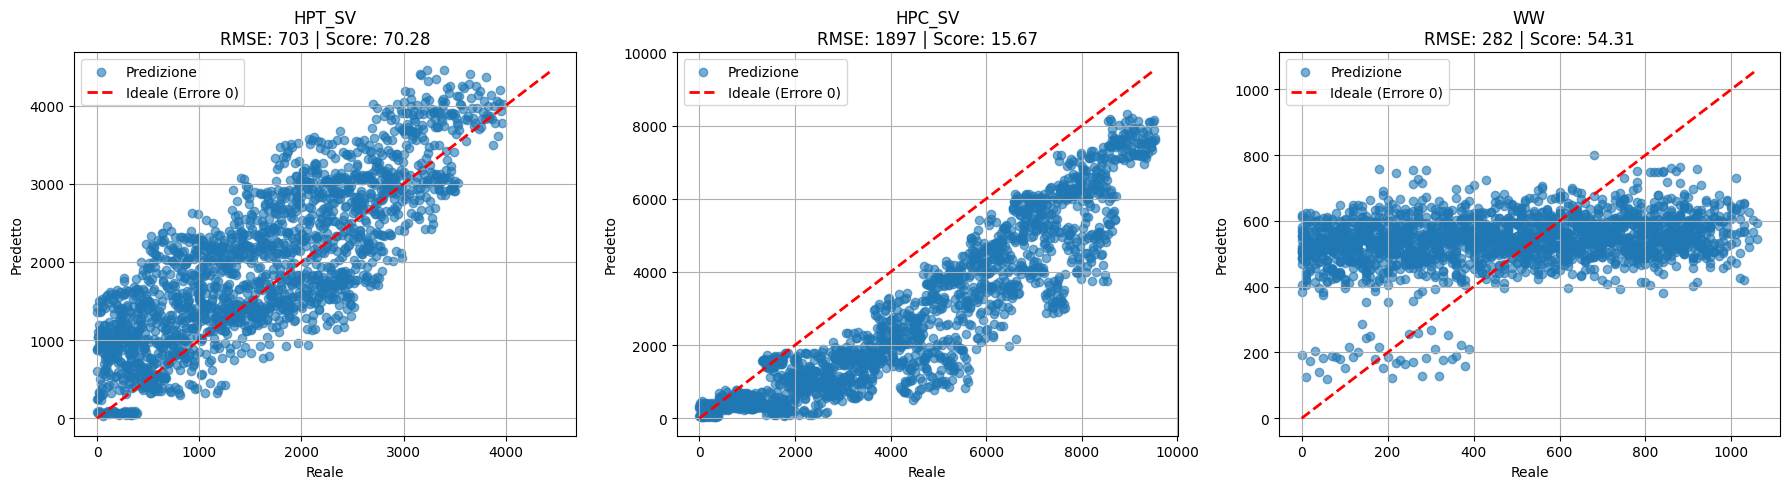

In [8]:
#in questo esempio usiamo il training set come train e validation


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# ==============================================================================
# 1. FUNZIONI DI PREPROCESSING
# ==============================================================================
def process_dataset(df):
    """Aggrega i dati per volo (Cruise Only)."""
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # Identifica colonne presenti
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    meta_cols = [c for c in ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs'] if c in df.columns]
    target_cols = [c for c in ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_WW'] if c in df.columns]

    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    for col in meta_cols: agg_dict[col] = 'max'
    for col in target_cols: agg_dict[col] = 'first'
    
    if 'ESN' in df.columns and 'Cycles_Since_New' in df.columns:
        return df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
    return pd.DataFrame()

# ==============================================================================
# 2. METRICA UFFICIALE
# ==============================================================================
def get_official_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/float(max_val) if component_type == 'WW' else 2/float(max_val)
    
    weight = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(weight * (error ** 2) * beta)

# ==============================================================================
# 3. MAIN (CON SPLIT INTELLIGENTE)
# ==============================================================================
def main():
    print("--- 1. CARICAMENTO DATI ---")
    try:
        # Carichiamo SOLO il training set completo
        df_full = pd.read_csv('data/train/training_data.csv')
        print(f"Dataset completo caricato: {df_full.shape} righe")
    except FileNotFoundError:
        print("ERRORE: Non trovo 'data/train/training_data.csv'"); return

    # --- SPLIT MANUALE PER AVERE LA VERITÀ ---
    # Troviamo la lista dei motori disponibili
    all_engines = df_full['ESN'].unique()
    print(f"Motori disponibili: {all_engines}")
    
    # Usiamo l'ULTIMO motore come Validation (Test), tutti gli altri come Training
    val_engine_id = all_engines[-1] 
    train_engines = all_engines[:-1]
    
    print(f"\n--- CONFIGURAZIONE SPLIT ---")
    print(f"TRAINING su motori: {train_engines}")
    print(f"VALIDATION (Test) su motore: {val_engine_id}")
    print("(Uso questo motore per calcolare l'errore perché di lui ho le risposte!)")

    # Dividiamo il dataset grezzo
    df_train_raw = df_full[df_full['ESN'].isin(train_engines)]
    df_val_raw = df_full[df_full['ESN'] == val_engine_id]

    # --- 2. PREPROCESSING ---
    print("\n--- 2. PREPROCESSING ---")
    df_train = process_dataset(df_train_raw)
    df_val = process_dataset(df_val_raw)

    # --- 3. DEFINIZIONE FEATURE ---
    features = [c for c in df_train.columns if 'Sensed_' in c or 'Cumulative_' in c]
    X_train = df_train[features]
    X_val = df_val[features]

    # --- 4. ADDESTRAMENTO E CALCOLO ERRORE ---
    print("\n--- 3. ADDESTRAMENTO E RISULTATI ---")
    targets = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    results = {}

    for target in targets:
        if target not in df_train.columns: continue
        
        print(f"\nAnalisi Target: {target}")
        
        # Training
        model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
        model.fit(X_train, df_train[target])
        
        # Prediction
        y_pred = model.predict(X_val)
        y_true = df_val[target] # Qui ESISTE perché viene dal training split!
        
        # Calcolo Errori
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        comp_type = 'WW' if 'WW' in target else ('HPC' if 'HPC' in target else 'HPT')
        score = get_official_score(y_true.values, y_pred, comp_type)
        
        print(f"   -> RMSE (Errore Medio): {rmse:.2f} cicli")
        print(f"   -> SCORE PHM (Punteggio Gara): {score:.4f}")
        
        results[target] = {'true': y_true, 'pred': y_pred, 'rmse': rmse, 'score': score}

    # --- 5. GRAFICI ---
    print("\n--- 4. GENERAZIONE GRAFICI ---")
    if results:
        fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
        if len(results) == 1: axes = [axes]
        
        for i, (target, res) in enumerate(results.items()):
            ax = axes[i]
            # Plot Punti
            ax.scatter(res['true'], res['pred'], alpha=0.6, label='Predizione')
            # Plot Linea Ideale Rossa
            min_v = min(res['true'].min(), res['pred'].min())
            max_v = max(res['true'].max(), res['pred'].max())
            ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=2, label='Ideale (Errore 0)')
            
            clean_name = target.replace('Cycles_to_', '')
            ax.set_title(f"{clean_name}\nRMSE: {res['rmse']:.0f} | Score: {res['score']:.2f}")
            ax.set_xlabel('Reale')
            ax.set_ylabel('Predetto')
            ax.legend()
            ax.grid(True)
            
        plt.tight_layout()
        plt.savefig('error_analysis.png')
        print("Grafico salvato come 'error_analysis.png'")
        plt.show()

if __name__ == "__main__":
    main()

Caricamento e preparazione dati...

--- CLASSIFICA FEATURE PIÙ IMPORTANTI ---

TARGET: Cycles_to_HPT_SV
   Cumulative_WWs: 0.5575
   Cumulative_HPT_SVs: 0.1067
   Sensed_VAFN: 0.0748
   Cumulative_HPC_SVs: 0.0663
   Sensed_T3: 0.0400

TARGET: Cycles_to_HPC_SV
   Cumulative_WWs: 0.6217
   Cumulative_HPC_SVs: 0.1245
   Cumulative_HPT_SVs: 0.0955
   Sensed_VAFN: 0.0463
   Sensed_T5: 0.0155

TARGET: Cycles_to_WW
   Sensed_T5: 0.0968
   Cumulative_WWs: 0.0852
   Sensed_T45: 0.0740
   Sensed_VAFN: 0.0677
   Sensed_T3: 0.0641

Grafico salvato come 'feature_importance_analysis.png'


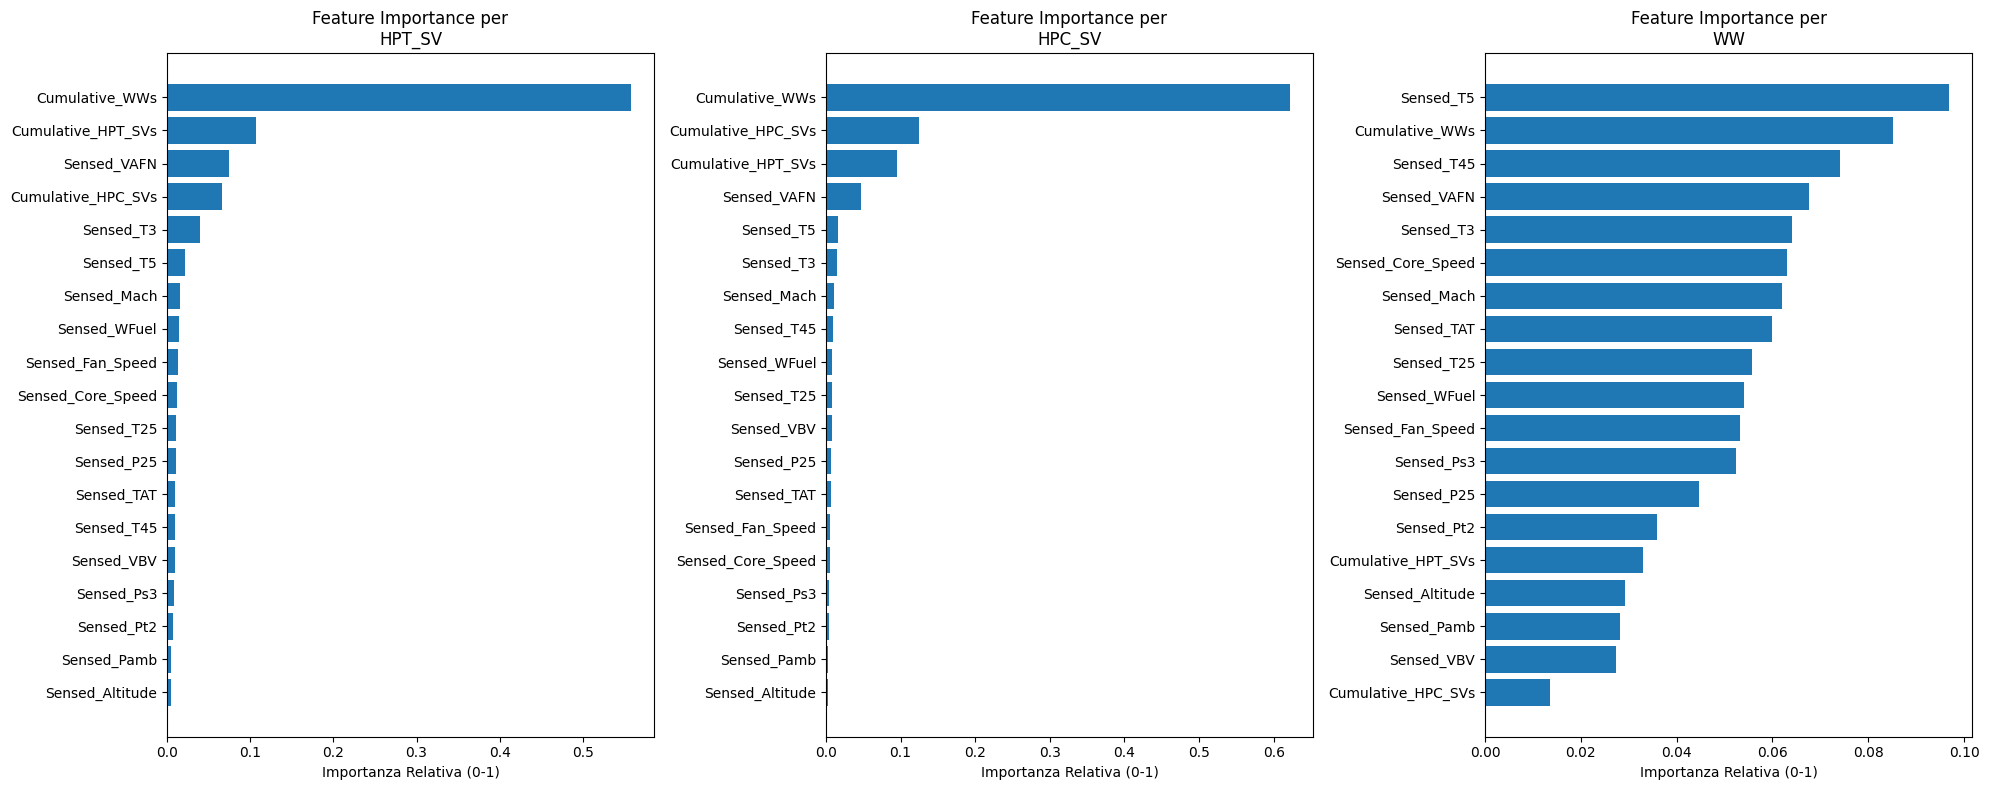

In [9]:
#valutazione migliori features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 1. CARICAMENTO E PREPROCESSING RAPIDO
# ==========================================
def load_and_prep():
    print("Caricamento e preparazione dati...")
    df = pd.read_csv('data/train/training_data.csv') # Assicurati il percorso sia giusto
    
    # Filtro "Cruise Only"
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # Aggregazione
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    # Aggiungiamo i cumulativi se presenti, sono importanti!
    meta_cols = [c for c in ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs'] if c in df.columns]
    target_cols = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    
    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    for col in meta_cols: agg_dict[col] = 'max'
    for col in target_cols: agg_dict[col] = 'first'
    
    df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
    return df_grouped, sensor_cols + meta_cols

# ==========================================
# 2. CALCOLO IMPORTANZA FEATURE
# ==========================================
def analyze_feature_importance():
    df, features = load_and_prep()
    targets = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    
    # Prepariamo il grafico
    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    
    print("\n--- CLASSIFICA FEATURE PIÙ IMPORTANTI ---")
    
    for i, target in enumerate(targets):
        # Addestriamo un modello veloce
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(df[features], df[target])
        
        # Estraiamo l'importanza
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1] # Indici ordinati decrescenti
        
        # Stampiamo la Top 5 in console
        print(f"\nTARGET: {target}")
        top_5_indices = indices[:5]
        for idx in top_5_indices:
            print(f"   {features[idx]}: {importances[idx]:.4f}")
            
        # Disegniamo il grafico
        ax = axes[i]
        ax.barh(range(len(features)), importances[indices], align='center')
        ax.set_yticks(range(len(features)))
        ax.set_yticklabels([features[i] for i in indices])
        ax.invert_yaxis() # La più importante in alto
        ax.set_title(f"Feature Importance per\n{target.replace('Cycles_to_', '')}")
        ax.set_xlabel("Importanza Relativa (0-1)")

    plt.tight_layout()
    plt.savefig('feature_importance_analysis.png')
    print("\nGrafico salvato come 'feature_importance_analysis.png'")
    plt.show()

if __name__ == "__main__":
    analyze_feature_importance()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

def analyze_feature_importance_all_altitudes():
    # 1. Caricamento Dati
    print("Caricamento dati in corso...")
    df = pd.read_csv('/Users/lorenzogiannetti/Documents/GitHub/A-PHM-AMERICA-2025/validation_data_cleaned_radical.csv')
    
    # 2. Preprocessing (TUTTE LE ALTITUDINI)
    # Non applichiamo nessun filtro df['Sensed_Altitude'] > 20000
    # Usiamo tutto il dataset grezzo.
    
    # Identifica colonne
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    meta_cols = [c for c in ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs'] if c in df.columns]
    target_cols = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    
    # Aggregazione per Volo
    # Usiamo: Media per sensori, Max per contatori, Primo valore per i target
    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    for col in meta_cols: agg_dict[col] = 'max'
    for col in target_cols: agg_dict[col] = 'first'
    
    print("Aggregazione dati (media di tutte le fasi di volo)...")
    df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
    
    # 3. Gestione Valori Mancanti (CRUCIALE se usi tutte le altitudini)
    # Alcuni sensori potrebbero dare NaN in fasi transitorie. Li riempiamo con la media.
    features = sensor_cols + meta_cols
    X = df_grouped[features]
    
    imputer = SimpleImputer(strategy='mean')
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=features)
    
    # 4. Addestramento e Analisi
    targets = [t for t in target_cols if t in df.columns]
    
    # Prepariamo i grafici
    fig, axes = plt.subplots(1, len(targets), figsize=(20, 8))
    if len(targets) == 1: axes = [axes]
    
    print("\n--- CLASSIFICA FEATURE PIÙ IMPORTANTI ---")
    
    for i, target in enumerate(targets):
        y = df_grouped[target]
        
        # Addestriamo un modello veloce
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X_imputed, y)
        
        # Estraiamo importanza
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1] # Ordine decrescente
        
        print(f"\nTARGET: {target}")
        print("Top 5 Feature:")
        for idx in indices[:5]:
            print(f"   {features[idx]}: {importances[idx]:.4f}")
            
        # Disegniamo il grafico
        ax = axes[i]
        ax.barh(range(len(features)), importances[indices], align='center')
        ax.set_yticks(range(len(features)))
        ax.set_yticklabels([features[j] for j in indices])
        ax.invert_yaxis() # La più importante in alto
        ax.set_title(f"Feature Importance per\n{target.replace('Cycles_to_', '')}")
        ax.set_xlabel("Importanza Relativa (0-1)")

    plt.tight_layout()
    plt.savefig('feature_importance_all_altitudes.png')
    print("\nGrafico salvato come 'feature_importance_all_altitudes.png'")
    plt.show()

if __name__ == "__main__":
    analyze_feature_importance_all_altitudes()

Caricamento dati in corso...
Aggregazione dati (media di tutte le fasi di volo)...


KeyError: "Label(s) ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_WW'] do not exist"

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

def clean_and_aggregate_radical(df, is_training=True):
    """
    Rimuove Snapshot e Cumulative.
    Aggrega per volo calcolando Media, Max e Deviazione Standard dei sensori.
    """
    print(f"   -> Processing {df.shape[0]} righe grezze...")
    
    # 1. RIMOZIONE COLONNE NON UTILIZZABILI
    # Togliamo Snapshot (inutile/dannoso) e Cumulative (non presenti nel test)
    cols_to_drop = ['Snapshot', 'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
    # Togliamo solo quelle che esistono effettivamente nel df
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    
    # 2. IDENTIFICAZIONE SENSORI
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    
    # 3. DEFINIZIONE REGOLE DI AGGREGAZIONE (Feature Engineering)
    # Invece di una sola media, estraiamo più segnale possibile
    agg_dict = {}
    for col in sensor_cols:
        # Calcoliamo Media, Massimo (picco) e Stabilità (std)
        agg_dict[col] = ['mean', 'max', 'std']
    
    # Gestione Target (se è training set)
    target_cols = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    if is_training:
        for col in target_cols:
            if col in df.columns:
                agg_dict[col] = 'first' # Il target è costante per tutto il volo
    
    # 4. AGGREGAZIONE
    # Raggruppa per Motore e Ciclo
    if 'ESN' in df.columns and 'Cycles_Since_New' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        # 5. APPIATTIMENTO NOMI COLONNE (Flattening)
        # Pandas crea un indice multi-livello (es. Sensed_T5 -> mean). Lo facciamo diventare Sensed_T5_mean
        new_columns = []
        for col_name, stat_name in df_grouped.columns:
            if stat_name: # Se c'è una statistica (mean, max, std)
                new_columns.append(f"{col_name}_{stat_name}")
            else: # Per ESN e index
                new_columns.append(col_name)
        
        df_grouped.columns = new_columns
        df_grouped = df_grouped.reset_index()
        
        # Gestione NaN generati dalla deviazione standard (std) se c'è un solo snapshot
        df_grouped = df_grouped.fillna(0)
        
        print(f"   -> Risultato: {df_grouped.shape[0]} voli. Feature generate: {df_grouped.shape[1]}")
        return df_grouped
    else:
        print("ERRORE: Colonne chiave mancanti.")
        return pd.DataFrame()

# ==============================================================================
# MAIN
# ==============================================================================
def main():
    # --- A. TRAINING SET ---
    print("--- 1. PULIZIA TRAINING SET ---")
    try:
        df_train = pd.read_csv('training_data.csv') # O il tuo percorso
        df_train_clean = clean_and_aggregate_radical(df_train, is_training=True)
        
        # Salviamo
        df_train_clean.to_csv('training_data_cleaned_radical.csv', index=False)
        print("Salvataggio completato: training_data_cleaned_radical.csv")
        
        # Mostriamo le nuove colonne create
        print("\nNuove Feature create (Esempio):")
        print([c for c in df_train_clean.columns if 'Sensed_T5' in c])
        
    except FileNotFoundError:
        print("File training non trovato.")

    # --- B. VALIDATION SET (Se hai i file) ---
    print("\n--- 2. PULIZIA VALIDATION SET ---")
    path_val = "*.csv" # O la tua cartella
    all_files = glob.glob(path_val)
    if 'training_data.csv' in all_files: all_files.remove('training_data.csv')
    
    if all_files:
        li = []
        for f in all_files: li.append(pd.read_csv(f))
        df_val = pd.concat(li, ignore_index=True)
        
        # Fix colonna Cycles se necessario
        if 'Cycles' in df_val.columns: df_val.rename(columns={'Cycles': 'Cycles_Since_New'}, inplace=True)
        
        df_val_clean = clean_and_aggregate_radical(df_val, is_training=False)
        df_val_clean.to_csv('validation_data_cleaned_radical.csv', index=False)
        print("Salvataggio completato: validation_data_cleaned_radical.csv")
    else:
        print("Nessun file di validation trovato.")

if __name__ == "__main__":
    main()

--- 1. PULIZIA TRAINING SET ---
File training non trovato.

--- 2. PULIZIA VALIDATION SET ---
   -> Processing 8449 righe grezze...
   -> Risultato: 8449 voli. Feature generate: 50
Salvataggio completato: validation_data_cleaned_radical.csv


Processing 59702 righe...
Dataset creato: 8004 voli. Feature Totali: 53

--- AVVIO ANALISI FEATURE FISICHE ---
Analizzando 48 feature generate (Mean/Max/Std)...

Analisi per: Cycles_to_HPT_SV
   Top 3 Feature:
   - Sensed_Ps3_max: 0.2909
   - Sensed_P25_max: 0.2902
   - Sensed_VAFN_max: 0.0495

Analisi per: Cycles_to_HPC_SV
   Top 3 Feature:
   - Sensed_T5_mean: 0.1983
   - Sensed_TAT_mean: 0.0855
   - Sensed_Core_Speed_mean: 0.0834

Analisi per: Cycles_to_WW
   Top 3 Feature:
   - Sensed_T5_mean: 0.0424
   - Sensed_T5_max: 0.0391
   - Sensed_P25_max: 0.0381

Grafico salvato: physical_feature_importance.png


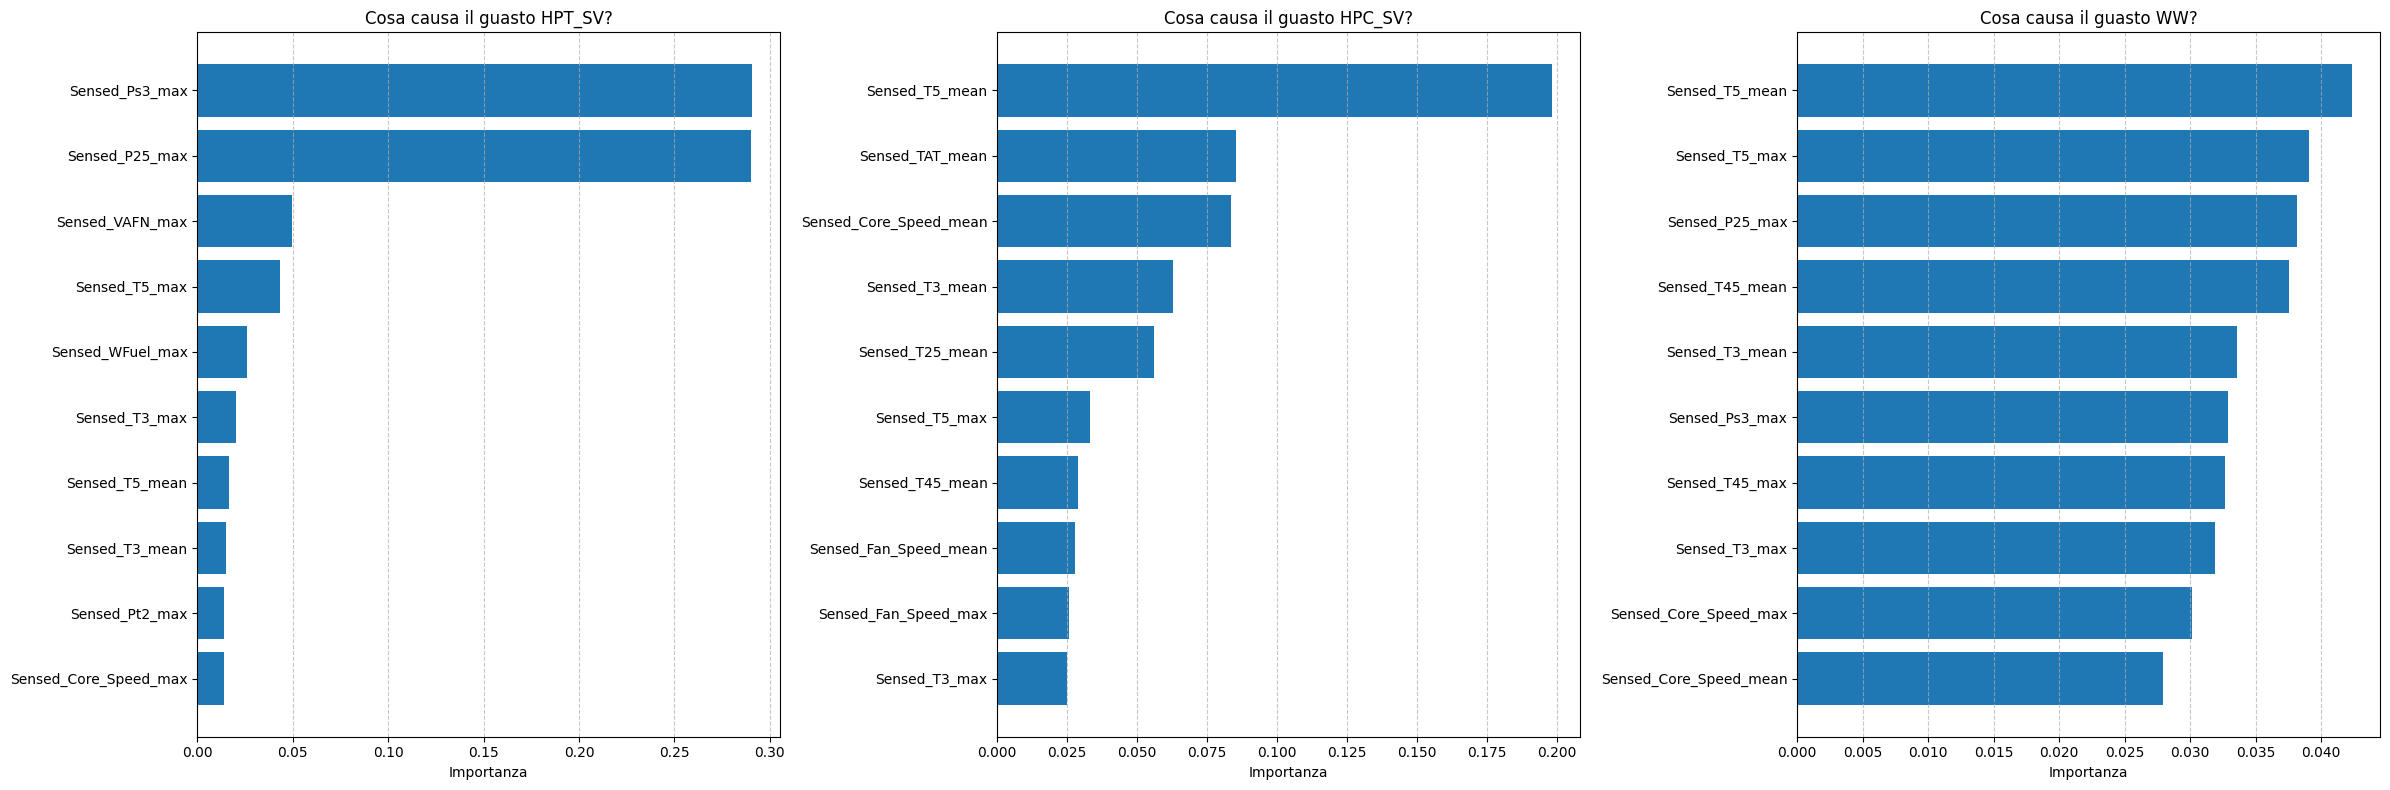

File salvato per uso futuro.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

# ==============================================================================
# 1. FUNZIONE DI PULIZIA "RADICALE" (CORRETTA)
# ==============================================================================
def create_radical_dataset(df):
    print(f"Processing {df.shape[0]} righe...")
    
    # 1. Rimuoviamo colonne "vietate" o inutili
    # Snapshot: Inutile. Cumulative: Non presenti nel test.
    cols_to_drop = ['Snapshot', 'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')
    
    # 2. Identifichiamo i gruppi di colonne
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    target_cols = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    target_cols = [c for c in target_cols if c in df.columns] # Solo quelli presenti
    
    # 3. Definiamo le aggregazioni
    agg_dict = {}
    
    # Per i sensori: Media, Massimo e Deviazione Standard
    for col in sensor_cols:
        agg_dict[col] = ['mean', 'max', 'std']
        
    # Per i target: Prendiamo il primo valore (First)
    for col in target_cols:
        agg_dict[col] = 'first'
        
    # 4. Eseguiamo l'aggregazione
    if 'ESN' not in df.columns or 'Cycles_Since_New' not in df.columns:
        print("ERRORE: Mancano le colonne chiave (ESN, Cycles).")
        return pd.DataFrame()

    df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
    
    # --- FIX NOMI COLONNE ---
    # Pandas crea un indice a due livelli (es. Sensed_T5 -> mean).
    # Dobbiamo appiattirlo, MA lasciare i Target col nome originale!
    
    new_columns = []
    for col_name, stat_name in df_grouped.columns:
        if col_name in target_cols:
            # SE È UN TARGET: Manteniamo il nome originale (senza _first)
            new_columns.append(col_name)
        elif stat_name: 
            # SE È UN SENSORE: Aggiungiamo il suffisso (es. _mean, _std)
            new_columns.append(f"{col_name}_{stat_name}")
        else:
            new_columns.append(col_name)
            
    df_grouped.columns = new_columns
    df_grouped = df_grouped.reset_index()
    
    # Gestione NaN: Se un volo ha 1 solo snapshot, la std è NaN. Mettiamo 0.
    df_grouped = df_grouped.fillna(0)
    
    print(f"Dataset creato: {df_grouped.shape[0]} voli. Feature Totali: {df_grouped.shape[1]}")
    return df_grouped

# ==============================================================================
# 2. ANALISI FEATURE IMPORTANCE
# ==============================================================================
def analyze_features(df):
    print("\n--- AVVIO ANALISI FEATURE FISICHE ---")
    
    # Definiamo Feature (X) e Target possibili (Y)
    targets = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    # Le feature sono tutte le colonne tranne ESN, Cicli e i Target stessi
    features = [c for c in df.columns if c not in targets and c not in ['ESN', 'Cycles_Since_New']]
    
    print(f"Analizzando {len(features)} feature generate (Mean/Max/Std)...")
    
    # Setup Grafico
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))
    
    for i, target_name in enumerate(targets):
        if target_name not in df.columns:
            print(f"Skipping {target_name} (non presente)")
            continue
            
        print(f"\nAnalisi per: {target_name}")
        X = df[features]
        y = df[target_name]
        
        # Addestramento Random Forest
        model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X, y)
        
        # Estrazione Importanza
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1] # Ordine decrescente
        
        # Top 10 Feature
        top_n = 10
        top_indices = indices[:top_n]
        
        print(f"   Top 3 Feature:")
        for idx in top_indices[:3]:
            print(f"   - {features[idx]}: {importances[idx]:.4f}")
            
        # Grafico
        ax = axes[i]
        ax.barh(range(top_n), importances[top_indices], align='center', color='#1f77b4')
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([features[j] for j in top_indices])
        ax.invert_yaxis()
        ax.set_title(f"Cosa causa il guasto {target_name.replace('Cycles_to_', '')}?")
        ax.set_xlabel("Importanza")
        ax.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig('physical_feature_importance.png')
    print("\nGrafico salvato: physical_feature_importance.png")
    plt.show()

# ==============================================================================
# MAIN
# ==============================================================================
if __name__ == "__main__":
    # 1. Carica
    try:
        df_raw = pd.read_csv('/Users/lorenzogiannetti/Documents/GitHub/A-PHM-AMERICA-2025/data/train/training_data.csv')
    except FileNotFoundError:
        print("ERRORE: Manca training_data.csv")
        exit()
        
    # 2. Pulisce (Dataset Radicale)
    df_radical = create_radical_dataset(df_raw)
    
    # 3. Analizza
    if not df_radical.empty:
        analyze_features(df_radical)
        
        # Salviamo il dataset pulito per il futuro
        df_radical.to_csv('training_data_cleaned_radical.csv', index=False)
        print("File salvato per uso futuro.")

In [ ]:
#PULIZIA DEI DATI

import pandas as pd
import os
 
# --- CONFIGURAZIONE ---
PATH_INPUT = 'data/train/training_data.csv'
DIR_OUTPUT = 'data_elaborated/train/'
FILE_OUTPUT = 'train_cleaned.csv'
 
def surgical_clean(df, is_training=True):
    print("Inizio pulizia...")
   
    # 1. Copia e pulizia base
    df_clean = df.copy()
    sensori_nomi = [c for c in df_clean.columns if 'Sensed' in c]
   
    # Rimuoviamo duplicati e filtriamo altitudine
    df_clean = df_clean.drop_duplicates(subset=['ESN', 'Cycles_Since_New', 'Snapshot'] + sensori_nomi)
    if 'Sensed_Altitude' in df_clean.columns:
        df_clean = df_clean[df_clean['Sensed_Altitude'] >= 0]
   
    # Bias 20k
    if is_training:
        df_clean = df_clean[df_clean['Cycles_Since_New'] < 20000]
 
    # 2. Clipping degli Outlier (Metodo Sicuro)
    print("Esecuzione Clipping Outlier per motore e fase di volo...")
   
    cleaned_chunks = []
    # Raggruppiamo per ESN e Snapshot
    grouped = df_clean.groupby(['ESN', 'Snapshot'])
   
    for (esn, snapshot), group in grouped:
        group = group.copy()
        for s in sensori_nomi:
            # Calcolo IQR
            Q1 = group[s].quantile(0.25)
            Q3 = group[s].quantile(0.75)
            IQR = Q3 - Q1
            # Applichiamo il clipping
            group[s] = group[s].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
       
        cleaned_chunks.append(group)
 
    # 3. Ricostruzione finale
    df_final = pd.concat(cleaned_chunks, ignore_index=True)
   
    # Rimuoviamo eventuali colonne "index" o "level_0" create da pandas
    df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|^index|^level_0')]
   
    return df_final
 
if __name__ == "__main__":
    if os.path.exists(PATH_INPUT):
        print(f"Caricamento {PATH_INPUT}...")
        df_raw = pd.read_csv(PATH_INPUT)
       
        # Esecuzione
        df_cleaned = surgical_clean(df_raw, is_training=True)
       
        # VERIFICA FINALE
        if 'ESN' in df_cleaned.columns:
            if not os.path.exists(DIR_OUTPUT): os.makedirs(DIR_OUTPUT)
            df_cleaned.to_csv(os.path.join(DIR_OUTPUT, FILE_OUTPUT), index=False)
            print("-" * 30)
            print(f"SUCCESSO TOTALE!")
            print(f"File salvato in: {os.path.join(DIR_OUTPUT, FILE_OUTPUT)}")
            print(f"Colonne salvate: {df_cleaned.columns.tolist()[:8]}...")
        else:
            print("\n!!! ERRORE CRITICO: ESN non trovato neanche con il metodo Chunk !!!")
            print(f"Colonne attuali: {df_cleaned.columns.tolist()}")
    else:
        print(f"ERRORE: File {PATH_INPUT} non trovato.")

Caricamento data/train/training_data.csv...
Inizio pulizia...
Esecuzione Clipping Outlier per motore e fase di volo...
------------------------------
SUCCESSO TOTALE!
File salvato in: data_elaborated/train/train_cleaned.csv
Colonne salvate: ['ESN', 'Cycles_Since_New', 'Snapshot', 'Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs', 'Sensed_Altitude', 'Sensed_Mach']...


In [ ]:
#Genera il train con i residui
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression
 
# --- 1. CONFIGURAZIONE PERCORSI ---
PATH_INPUT = 'data_elaborated/train/train_cleaned.csv'
DIR_OUTPUT = 'data_elaborated/train/'
FILE_OUTPUT = 'train_with_residuals.csv'
 
# Variabili Operative (X) - Definiscono l'ambiente di volo
S_O = ['Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb', 'Sensed_TAT', 'Sensed_Fan_Speed']
 
# Sensori di Degrado (y) - Quelli che vogliamo "pulire"
S_D = ['Sensed_T45', 'Sensed_T3', 'Sensed_WFuel', 'Sensed_Ps3', 'Sensed_Core_Speed']
 
def calculate_residuals(df):
    engine_results = []
    motori = df['ESN'].unique()
   
    print(f"Calcolo residui per {len(motori)} motori...")
   
    for esn in motori:
        # Isoliamo i dati del singolo motore
        engine_df = df[df['ESN'] == esn].copy()
       
        # Riordiniamo per sicurezza temporale
        engine_df = engine_df.sort_values('Cycles_Since_New')
       
        # Gestione valori mancanti (necessaria per la regressione)
        engine_df = engine_df.ffill().bfill()
       
        for sensor in S_D:
            # Addestriamo il modello "nominale" del motore
            X = engine_df[S_O].values
            y = engine_df[sensor].values
           
            # Regressione Lineare: impara il comportamento sano in base alla quota
            model = LinearRegression()
            model.fit(X, y)
           
            # Calcoliamo la differenza (Residuo)
            y_pred = model.predict(X)
            engine_df[f"{sensor}_res"] = y - y_pred
           
        engine_results.append(engine_df)
        print(f" > Motore {esn} completato.")
       
    return pd.concat(engine_results, ignore_index=True)
 
# --- 2. ESECUZIONE ---
if __name__ == "__main__":
    if os.path.exists(PATH_INPUT):
        print(f"Lettura dati puliti da: {PATH_INPUT}")
        df_cleaned = pd.read_csv(PATH_INPUT)
       
        # Calcolo
        df_final = calculate_residuals(df_cleaned)
       
        # Salvataggio
        if not os.path.exists(DIR_OUTPUT): os.makedirs(DIR_OUTPUT)
        df_final.to_csv(os.path.join(DIR_OUTPUT, FILE_OUTPUT), index=False)
       
        print("-" * 30)
        print(f"SUCCESSO: Creati residui per {len(S_D)} sensori.")
        print(f"File salvato: {os.path.join(DIR_OUTPUT, FILE_OUTPUT)}")
    else:
        print(f"ERRORE: File {PATH_INPUT} non trovato!")

--- 1. CARICAMENTO DATI ---
Dataset completo caricato: (58736, 30) righe

--- 2. PREPROCESSING COMPLETO ---
Dataset aggregato pronto: (8000, 29) righe (voli)
Feature usate: 24
Motori unici (Groups): [101 102 103 104]

--- 3. AVVIO CROSS-VALIDATION (GroupKFold) ---

Analisi Target: Cycles_to_HPT_SV ======================
   Fold 1: Val su ESN [104] -> RMSE: 687.69 | Score: 77.9761
   Fold 2: Val su ESN [103] -> RMSE: 551.57 | Score: 20.6947
   Fold 3: Val su ESN [102] -> RMSE: 459.56 | Score: 30.8235
   Fold 4: Val su ESN [101] -> RMSE: 406.33 | Score: 11.8082
   >>> MEDIA Cycles_to_HPT_SV: RMSE 526.29 | SCORE 35.3256

Analisi Target: Cycles_to_HPC_SV ======================
   Fold 1: Val su ESN [104] -> RMSE: 1587.01 | Score: 31.1922
   Fold 2: Val su ESN [103] -> RMSE: 1449.37 | Score: 93.9919
   Fold 3: Val su ESN [102] -> RMSE: 758.91 | Score: 8.3529
   Fold 4: Val su ESN [101] -> RMSE: 1069.65 | Score: 35.1736
   >>> MEDIA Cycles_to_HPC_SV: RMSE 1216.23 | SCORE 42.1777

Analisi Tar

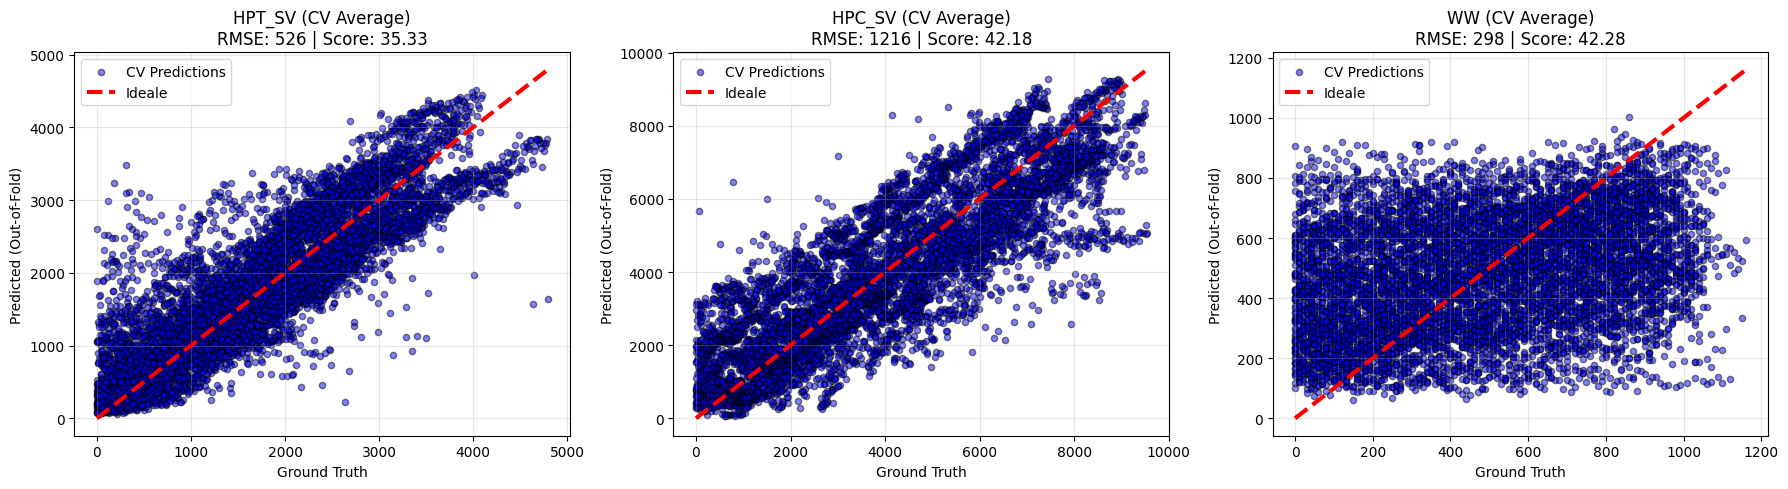

In [21]:
#group k-fold validation 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold

# ==============================================================================
# 1. FUNZIONI DI PREPROCESSING
# ==============================================================================
def process_dataset(df):
    """Aggrega i dati per volo (Cruise Only)."""
    # Filtro Altitudine
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 10000].copy()
    
    # Identifica colonne presenti
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    # NOTA: Se vuoi escludere le cumulative perché non ci sono nel test, togli questa riga
    meta_cols = [c for c in ['Cumulative_WWs', 'Cumulative_HPC_SVs', 'Cumulative_HPT_SVs'] if c in df.columns]
    target_cols = [c for c in ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV', 'Cycles_to_WW'] if c in df.columns]

    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    for col in meta_cols: agg_dict[col] = 'max'
    for col in target_cols: agg_dict[col] = 'first'
    
    if 'ESN' in df.columns and 'Cycles_Since_New' in df.columns:
        return df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
    return pd.DataFrame()

# ==============================================================================
# 2. METRICA UFFICIALE
# ==============================================================================
def get_official_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    # Protezione per divisione zero
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/float(max_val) if component_type == 'WW' else 2/float(max_val)
    
    weight = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(weight * (error ** 2) * beta)

# ==============================================================================
# 3. MAIN (CON CROSS VALIDATION)
# ==============================================================================
def main():
    print("--- 1. CARICAMENTO DATI ---")
    try:
        df_full = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
        print(f"Dataset completo caricato: {df_full.shape} righe")
    except FileNotFoundError:
        print("ERRORE: Non trovo il file training_data.csv"); return

    # --- 2. PREPROCESSING UNICO ---
    print("\n--- 2. PREPROCESSING COMPLETO ---")
    # Processiamo tutto il dataset insieme
    df_processed = process_dataset(df_full)
    print(f"Dataset aggregato pronto: {df_processed.shape} righe (voli)")

    # Definizione Feature e Gruppi
    features = [c for c in df_processed.columns if 'Sensed_' in c or 'Cumulative_' in c]
    X = df_processed[features]
    groups = df_processed['ESN'] # IMPORTANTE: Questo assicura che non spezziamo i motori a metà
    
    print(f"Feature usate: {len(features)}")
    print(f"Motori unici (Groups): {groups.unique()}")

    # --- 3. CROSS VALIDATION ---
    print("\n--- 3. AVVIO CROSS-VALIDATION (GroupKFold) ---")
    
    targets = ['Cycles_to_HPT_SV', 'Cycles_to_HPC_SV', 'Cycles_to_WW']
    
    # Dizionario per salvare tutti i risultati per il grafico finale
    final_plot_data = {} 

    # Impostiamo 4 Fold (o quanti motori hai diviso per 2)
    # Esempio: Se hai 8 motori, n_splits=4 significa 2 motori nel validation set ogni volta.
    gkf = GroupKFold(n_splits=4)

    for target in targets:
        if target not in df_processed.columns: continue
        
        y = df_processed[target]
        print(f"\nAnalisi Target: {target} ======================")
        
        fold_scores = []
        fold_rmses = []
        
        # Liste per accumulare predizioni e verità di tutti i fold (per fare un unico grafico)
        all_y_true = []
        all_y_pred = []

        # Ciclo sui Fold
        for fold_i, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
            # Split dei dati
            X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
            y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
            
            # Addestramento
            model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
            model.fit(X_train_cv, y_train_cv)
            
            # Predizione
            y_pred_cv = model.predict(X_val_cv)
            
            # Calcolo Metriche Fold corrente
            rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred_cv))
            comp_type = 'WW' if 'WW' in target else ('HPC' if 'HPC' in target else 'HPT')
            score = get_official_score(y_val_cv.values, y_pred_cv, comp_type)
            
            # Salvataggio metriche
            fold_rmses.append(rmse)
            fold_scores.append(score)
            
            # Accumulo dati per plot
            all_y_true.extend(y_val_cv)
            all_y_pred.extend(y_pred_cv)
            
            # Info motori usati in validazione
            val_engines = df_processed.iloc[val_idx]['ESN'].unique()
            print(f"   Fold {fold_i+1}: Val su ESN {val_engines} -> RMSE: {rmse:.2f} | Score: {score:.4f}")

        # Risultati medi
        avg_rmse = np.mean(fold_rmses)
        avg_score = np.mean(fold_scores)
        print(f"   >>> MEDIA {target}: RMSE {avg_rmse:.2f} | SCORE {avg_score:.4f}")
        
        final_plot_data[target] = {
            'true': np.array(all_y_true),
            'pred': np.array(all_y_pred),
            'rmse': avg_rmse,
            'score': avg_score
        }

    # --- 4. GRAFICI ---
    print("\n--- 4. GENERAZIONE GRAFICI (CROSS-VALIDATED) ---")
    if final_plot_data:
        fig, axes = plt.subplots(1, len(final_plot_data), figsize=(6 * len(final_plot_data), 5))
        if len(final_plot_data) == 1: axes = [axes]
        
        for i, (target, res) in enumerate(final_plot_data.items()):
            ax = axes[i]
            
            # Scatter plot
            ax.scatter(res['true'], res['pred'], alpha=0.5, c='blue', edgecolors='k', s=20, label='CV Predictions')
            
            # Linea Ideale
            min_v = min(res['true'].min(), res['pred'].min())
            max_v = max(res['true'].max(), res['pred'].max())
            ax.plot([min_v, max_v], [min_v, max_v], 'r--', lw=3, label='Ideale')
            
            clean_name = target.replace('Cycles_to_', '')
            ax.set_title(f"{clean_name} (CV Average)\nRMSE: {res['rmse']:.0f} | Score: {res['score']:.2f}")
            ax.set_xlabel('Ground Truth')
            ax.set_ylabel('Predicted (Out-of-Fold)')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.savefig('cross_validation_results.png')
        print("Grafico salvato come 'cross_validation_results.png'")
        plt.show()

if __name__ == "__main__":
    main()

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold

# ==============================================================================
# 1. FUNZIONI DI FEATURE ENGINEERING (TRENDS)
# ==============================================================================
def add_trend_features(df, sensor_cols, window_size=5):
    """
    Calcola medie mobili (Smoothing) e pendenze (Rate of Change).
    Molto più robusto del confronto col primo volo.
    """
    # Ordina per garantire la sequenza temporale
    df = df.sort_values(by=['ESN', 'Cycles_Since_New'])
    
    # Raggruppa per motore per non mischiare dati di motori diversi
    grouped = df.groupby('ESN')
    
    for col in sensor_cols:
        # 1. Rolling Mean (Lisciatura): Toglie il rumore del singolo volo
        # min_periods=1 garantisce che non abbiamo NaN all'inizio
        df[f"{col}_smooth"] = grouped[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
        
        # 2. Gradient (Pendenza): Quanto sta cambiando rispetto a N voli fa?
        # Indica la velocità di degrado.
        df[f"{col}_grad"] = grouped[col].diff(periods=window_size).fillna(0)
        
    return df

# ==============================================================================
# 2. PREPROCESSING: DUE STRATEGIE
# ==============================================================================

def prepare_mechanical_data(df):
    """PIPELINE A: HPT/HPC (Usura Meccanica) - Cruise Stability"""
    # 1. Filtro Crociera (> 20k ft)
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # 2. Aggregazione (Media per stabilità)
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    
    agg_dict = {}
    for col in sensor_cols: agg_dict[col] = 'mean'
    
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        
        # Rinomina feature base
        base_features = []
        for c in df_grouped.columns:
            if c in targets or c in ['ESN', 'Cycles_Since_New']: continue
            new_name = f"{c}_mean"
            df_grouped.rename(columns={c: new_name}, inplace=True)
            base_features.append(new_name)
            
        # --- AGGIUNTA TRENDS ---
        df_grouped = add_trend_features(df_grouped, base_features)
        
        return df_grouped
    return pd.DataFrame()

def prepare_wash_data(df):
    """PIPELINE B: Water Wash - Efficienza e Picchi"""
    df = df.copy()
    
    # 1. Filtro Potenza (Solo motore sotto sforzo, > 8000 RPM)
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    # 2. Ratio Fisici (Efficienza)
    if 'Sensed_WFuel' in df.columns and 'Sensed_Core_Speed' in df.columns:
        # Se consumo più carburante per la stessa velocità -> Motore Sporco
        df['Eff_Fuel'] = df['Sensed_WFuel'] / df['Sensed_Core_Speed']
        
    if 'Sensed_T5' in df.columns and 'Sensed_Ps3' in df.columns:
        # Se T5 è alta rispetto alla pressione -> Compressore Sporco
        df['Eff_Temp'] = df['Sensed_T5'] / df['Sensed_Ps3']

    # 3. Aggregazione
    # Per il WW i picchi (max) sono importanti
    cols_to_agg = ['Sensed_T5', 'Sensed_WFuel', 'Eff_Fuel', 'Eff_Temp']
    # Filtriamo solo quelle presenti
    cols_to_agg = [c for c in cols_to_agg if c in df.columns]
    
    agg_dict = {}
    for col in cols_to_agg: agg_dict[col] = 'max' # Picco
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        # Rinomina
        new_cols = []
        base_features = []
        for col in df_grouped.columns:
            if col == 'Cycles_to_WW': 
                new_cols.append(col)
            else:
                name = f"{col}_max"
                new_cols.append(name)
                base_features.append(name)
                
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        
        # --- AGGIUNTA TRENDS ---
        # Qui il trend è fondamentale: se il picco T5 sale costantemente, serve lavaggio
        df_grouped = add_trend_features(df_grouped, base_features)
        
        return df_grouped
    return pd.DataFrame()

# ==============================================================================
# 3. METRICHE E MAIN
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def main():
    print("--- 1. CARICAMENTO DATI ---")
    try:
        df_raw = pd.read_csv('data/train/training_data.csv')
    except:
        print("File non trovato."); return

    # --- 2. PREPARAZIONE DATASET ---
    print("\n--- 2. CREAZIONE DATASET CON TRENDS ---")
    df_mech = prepare_mechanical_data(df_raw)
    df_wash = prepare_wash_data(df_raw)
    print(f"Dataset Mechanical: {df_mech.shape}")
    print(f"Dataset Wash: {df_wash.shape}")

    # --- 3. CROSS VALIDATION ---
    print("\n--- 3. AVVIO GROUP CV ---")
    gkf = GroupKFold(n_splits=4)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT'},
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC'},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW'}
    ]

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        
        if target not in df.columns: continue
        
        # Feature Selection:
        # Importante: Usiamo 'Cycles_Since_New' + Sensori + Trends
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        rmses, scores = [], []
        
        print(f"\n>>> {ctype} (Features: {len(features)}) <<<")
        
        for i, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Parametri Random Forest più conservativi per evitare overfitting
            model = RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=5, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            
            pred = model.predict(X_val)
            
            rmse = np.sqrt(mean_squared_error(y_val, pred))
            score = get_score(y_val.values, pred, ctype)
            
            rmses.append(rmse)
            scores.append(score)
            print(f"   Fold {i+1}: RMSE={rmse:.0f} | Score={score:.4f}")
            
        print(f"   [MEDIA {ctype}] RMSE: {np.mean(rmses):.2f} | SCORE: {np.mean(scores):.4f}")

if __name__ == "__main__":
    main()

--- 1. CARICAMENTO DATI ---

--- 2. CREAZIONE DATASET CON TRENDS ---
Dataset Mechanical: (7845, 52)
Dataset Wash: (7914, 15)

--- 3. AVVIO GROUP CV ---

>>> HPT (Features: 49) <<<
   Fold 1: RMSE=757 | Score=61.5185
   Fold 2: RMSE=777 | Score=133.9408
   Fold 3: RMSE=888 | Score=52.3716
   Fold 4: RMSE=1012 | Score=190.6354
   [MEDIA HPT] RMSE: 858.68 | SCORE: 109.6166

>>> HPC (Features: 49) <<<
   Fold 1: RMSE=2012 | Score=171.2849
   Fold 2: RMSE=1332 | Score=108.4535
   Fold 3: RMSE=1992 | Score=82.7892
   Fold 4: RMSE=1813 | Score=224.0297
   [MEDIA HPC] RMSE: 1787.43 | SCORE: 146.6393

>>> WW (Features: 13) <<<
   Fold 1: RMSE=280 | Score=45.3846
   Fold 2: RMSE=284 | Score=50.0161
   Fold 3: RMSE=295 | Score=36.2180
   Fold 4: RMSE=282 | Score=42.8801
   [MEDIA WW] RMSE: 285.24 | SCORE: 43.6247


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 

def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    """
    Genera il grafico comparativo: Reale vs Predetto vs Safe.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcoliamo la versione "Safe" (ulteriore margine oltre al modello)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))

    # 1. RUL REALE (La Verità) - Linea Verde
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)

    # 2. PREDIZIONE MODELLO - Linea Rossa
    plt.plot(y_pred, label='Predizione Modello', color='red', 
             alpha=0.6, linestyle='--', linewidth=1.5)

    # 3. PREDIZIONE SAFE - Linea Blu
    if margin > 0:
        plt.plot(y_pred_safe, label=f'Predizione Safe (-{margin})', 
                 color='blue', alpha=0.9, linewidth=2)

    # 4. RIFERIMENTO CLIPPING
    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limit ({clip_limit})')

    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli nel Validation Set)', fontsize=12)
    plt.ylabel('Cicli Rimanenti (RUL)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
# ==============================================================================
# 2. PREPROCESSING PIPELINES (Mechanical vs Wash)
# ==============================================================================
def prepare_mechanical_data(df):
    """Pipeline HPT/HPC: Cruise Only + Smoothing"""
    # 1. Filtro Crociera (> 20k ft)
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    
    agg_dict = {col: 'mean' for col in sensor_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        
        # Smoothing (Media Mobile)
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in sensor_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        
        # Gestione NaN residui
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
        
    return pd.DataFrame()

def prepare_wash_data(df):
    """Pipeline WW: Filtro Idle + Ratios + Max"""
    df = df.copy()
    
    # 1. Filtro Idle (Solo motore sotto sforzo)
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    # 2. Ratios (Gestione divisione per zero)
    if 'Sensed_WFuel' in df.columns and 'Sensed_Core_Speed' in df.columns:
        df['Ratio_Fuel_Speed'] = df['Sensed_WFuel'] / df['Sensed_Core_Speed']
        df['Ratio_Fuel_Speed'] = df['Ratio_Fuel_Speed'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    cols = ['Ratio_Fuel_Speed', 'Sensed_T5', 'Sensed_T45']
    use_cols = [c for c in cols if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        # Flatten nomi colonne
        new_cols = []
        for c, s in df_grouped.columns:
            if c == 'Cycles_to_WW' or s == '': new_cols.append(c)
            else: new_cols.append(f"{c}_{s}")
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        
        # Smoothing
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        smooth_cols = [c for c in new_cols if 'Ratio' in c or 'T5' in c]
        for col in smooth_cols:
             df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
        
    return pd.DataFrame()

# ==============================================================================
# 3. METRICA SCORE
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

# ==============================================================================
# VISUALIZZAZIONE PREDIZIONI 
# ==============================================================================

# ==============================================================================
# 4. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO DATI ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except FileNotFoundError:
        print("File non trovato."); return

    df_cleaned = df_raw

    # --- PASSO 2: CREAZIONE DATASET SPECIALIZZATI ---
    print("\n--- CREAZIONE DATASET (Mechanical & Wash) ---")
    df_mech = prepare_mechanical_data(df_cleaned)
    df_wash = prepare_wash_data(df_cleaned)
    
    gkf = GroupKFold(n_splits=4)
    
    # Parametri Alpha (Pessimismo) per Quantile Regression
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.3}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.3},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.4}  
    ]

    print("\n--- AVVIO TRAINING (CON CLEANING + QUANTILE) ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        
        if target not in df.columns: continue
        
        # Features
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        # Imputer di Sicurezza
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        rmses, scores = [], []
        
        print(f"\n>>> {ctype} (Alpha: {alpha_q}) <<<")
        
        for i, (train_idx, val_idx) in enumerate(gkf.split(X_clean, y, groups)):
            X_train, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Gradient Boosting Quantile
            model = GradientBoostingRegressor(
                loss='quantile', 
                alpha=alpha_q,
                n_estimators=100, 
                learning_rate=0.1,
                max_depth=5, 
                random_state=42
            )
            model.fit(X_train, y_train)
            
            pred = model.predict(X_val)
            pred = np.maximum(pred, 0) # Mai negativo
            
            rmse = np.sqrt(mean_squared_error(y_val, pred))
            score = get_score(y_val.values, pred, ctype)
            
            rmses.append(rmse)
            scores.append(score)
            print(f"   Fold {i+1}: RMSE={rmse:.0f} | Score={score:.4f}")
            
        print(f"   [MEDIA {ctype}] SCORE: {np.mean(scores):.4f}")

if __name__ == "__main__":
    main()

--- CARICAMENTO DATI ---

--- CREAZIONE DATASET (Mechanical & Wash) ---

--- AVVIO TRAINING (CON CLEANING + QUANTILE) ---

>>> HPT (Alpha: 0.3) <<<
   Fold 1: RMSE=487 | Score=15.9701
   Fold 2: RMSE=384 | Score=19.1258
   Fold 3: RMSE=550 | Score=9.4129
   Fold 4: RMSE=433 | Score=15.1765
   [MEDIA HPT] SCORE: 14.9213

>>> HPC (Alpha: 0.3) <<<
   Fold 1: RMSE=1552 | Score=19.2847
   Fold 2: RMSE=867 | Score=5.4586
   Fold 3: RMSE=915 | Score=18.3210
   Fold 4: RMSE=921 | Score=8.6229
   [MEDIA HPC] SCORE: 12.9218

>>> WW (Alpha: 0.4) <<<
   Fold 1: RMSE=308 | Score=34.8506
   Fold 2: RMSE=291 | Score=33.6583
   Fold 3: RMSE=283 | Score=44.7524
   Fold 4: RMSE=317 | Score=21.5023
   [MEDIA WW] SCORE: 33.6909


--- CARICAMENTO ---

--- DATASET ---

--- AVVIO TRAINING (Random Forest) ---

>>> HPT <<<
   Fold 1: Score=52.2497
   [Grafico] Generazione plot per ESN 104...


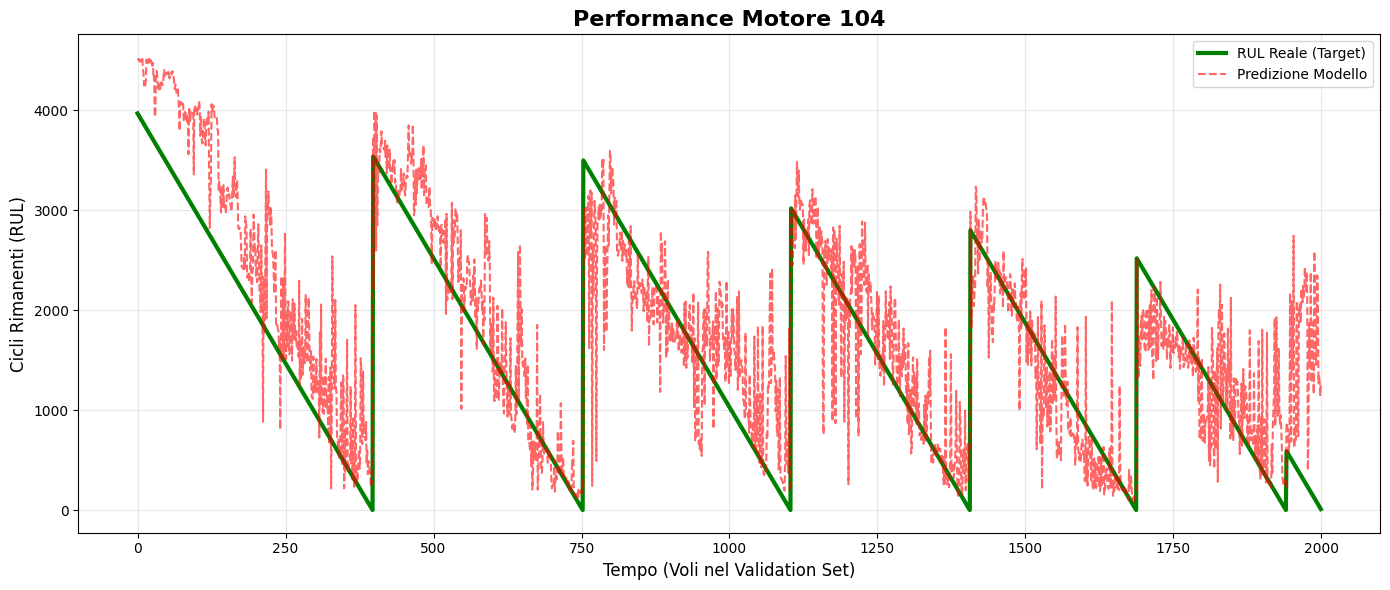

   Fold 2: Score=29.4162
   Fold 3: Score=22.7562
   Fold 4: Score=15.2421
   [MEDIA HPT] SCORE: 29.9161

>>> HPC <<<
   Fold 1: Score=18.6014
   [Grafico] Generazione plot per ESN 104...


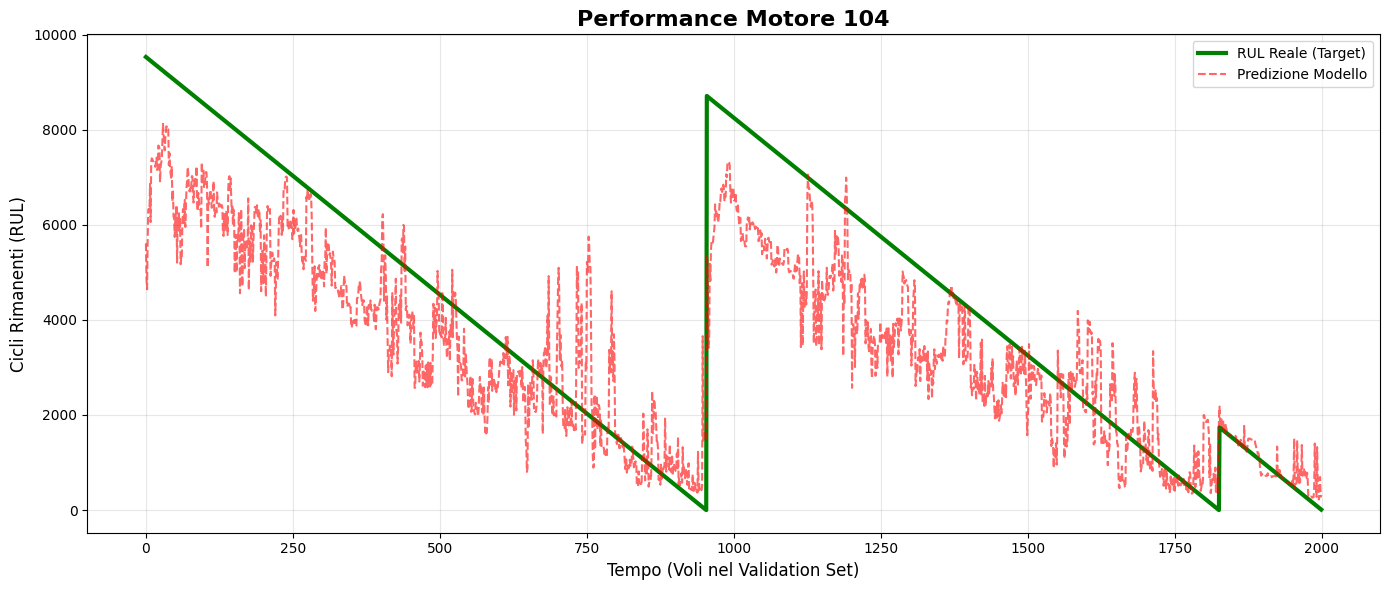

   Fold 2: Score=9.3396
   Fold 3: Score=38.4635
   Fold 4: Score=14.7060
   [MEDIA HPC] SCORE: 20.2776

>>> WW <<<
   Fold 1: Score=42.5876
   [Grafico] Generazione plot per ESN 104...


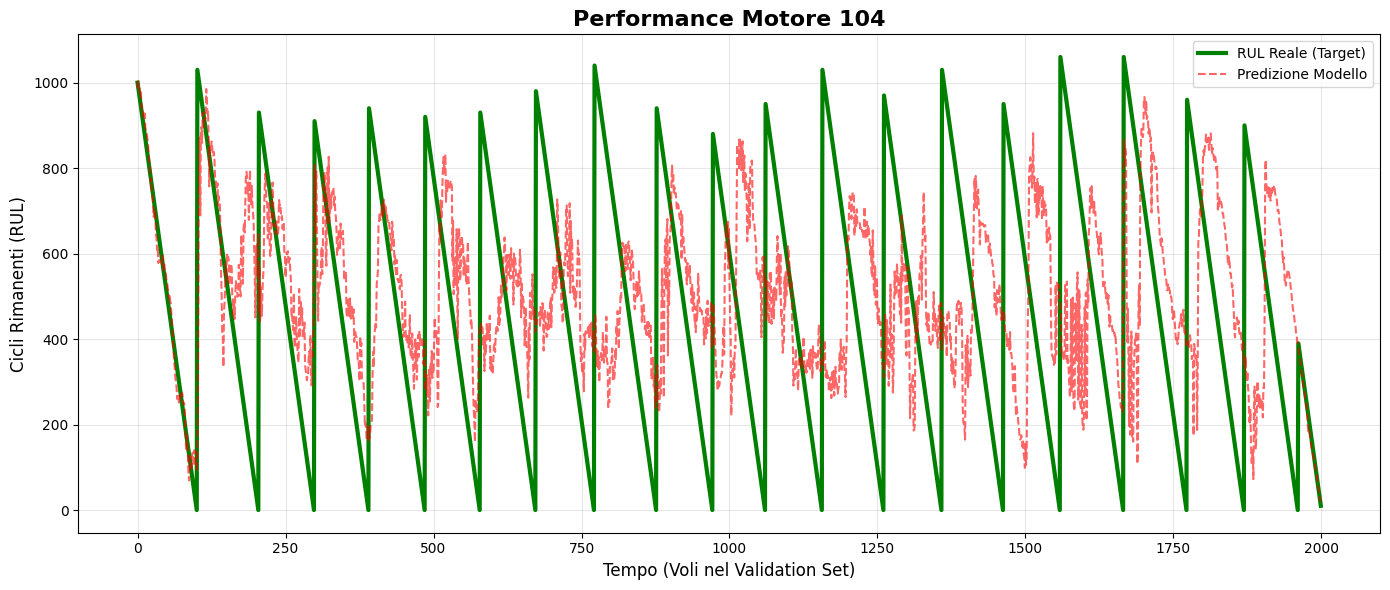

   Fold 2: Score=75.8737
   Fold 3: Score=55.1864
   Fold 4: Score=29.7841
   [MEDIA WW] SCORE: 50.8579


In [ ]:
#Train with residual, grafico nic, random forest

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 

# ==============================================================================
# 0. FUNZIONE GRAFICA DEL COLLEGA (NUOVA)
# ==============================================================================
def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    """
    Genera il grafico comparativo: Reale vs Predetto vs Safe.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calcoliamo la versione "Safe" (ulteriore margine oltre al modello)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))

    # 1. RUL REALE (La Verità) - Linea Verde
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)

    # 2. PREDIZIONE MODELLO - Linea Rossa
    plt.plot(y_pred, label='Predizione Modello', color='red', 
             alpha=0.6, linestyle='--', linewidth=1.5)

    # 3. PREDIZIONE SAFE - Linea Blu
    if margin > 0:
        plt.plot(y_pred_safe, label=f'Predizione Safe (-{margin})', 
                 color='blue', alpha=0.9, linewidth=2)

    # 4. RIFERIMENTO CLIPPING
    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limit ({clip_limit})')

    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli nel Validation Set)', fontsize=12)
    plt.ylabel('Cicli Rimanenti (RUL)', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, which='both', alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. PULIZIA DATI "CHIRURGICA"
# ==============================================================================
def surgical_clean(df, is_training=True):
    print("   -> Avvio Surgical Clean...")
    df_clean = df.copy()
    sensori_nomi = [c for c in df_clean.columns if 'Sensed' in c]
    
    df_clean = df_clean.drop_duplicates(subset=['ESN', 'Cycles_Since_New', 'Snapshot'] + sensori_nomi)
    
    if 'Sensed_Altitude' in df_clean.columns:
        df_clean = df_clean[df_clean['Sensed_Altitude'] >= 0]
    
    if is_training and 'Cycles_Since_New' in df_clean.columns:
        df_clean = df_clean[df_clean['Cycles_Since_New'] < 20000]

    cleaned_chunks = []
    grouped = df_clean.groupby(['ESN', 'Snapshot'])
    
    for (esn, snapshot), group in grouped:
        group = group.copy()
        for s in sensori_nomi:
            Q1 = group[s].quantile(0.25)
            Q3 = group[s].quantile(0.75)
            IQR = Q3 - Q1
            group[s] = group[s].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
        cleaned_chunks.append(group)

    if cleaned_chunks:
        df_final = pd.concat(cleaned_chunks, ignore_index=True)
        df_final = df_final.loc[:, ~df_final.columns.str.contains('^Unnamed|^index|^level_0')]
        return df_final
    else:
        return df_clean

# ==============================================================================
# 2. PREPROCESSING PIPELINES
# ==============================================================================
def prepare_mechanical_data(df):
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    agg_dict = {col: 'mean' for col in sensor_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in sensor_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
    return pd.DataFrame()

def prepare_wash_data(df):
    df = df.copy()
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    if 'Sensed_WFuel' in df.columns and 'Sensed_Core_Speed' in df.columns:
        df['Ratio_Fuel_Speed'] = df['Sensed_WFuel'] / df['Sensed_Core_Speed']
        df['Ratio_Fuel_Speed'] = df['Ratio_Fuel_Speed'].replace([np.inf, -np.inf], np.nan).fillna(0)
    
    cols = ['Ratio_Fuel_Speed', 'Sensed_T5', 'Sensed_T45']
    use_cols = [c for c in cols if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        new_cols = []
        for c, s in df_grouped.columns:
            if c == 'Cycles_to_WW' or s == '': new_cols.append(c)
            else: new_cols.append(f"{c}_{s}")
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        smooth_cols = [c for c in new_cols if 'Ratio' in c or 'T5' in c]
        for col in smooth_cols:
             df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
    return pd.DataFrame()

def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

# ==============================================================================
# 3. MAIN CON INTEGRAZIONE GRAFICO
# ==============================================================================
def main():
    print("--- CARICAMENTO ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except:
        print("File non trovato."); return

   #df_cleaned = surgical_clean(df_raw, is_training=True)
    df_cleaned = df_raw

    print("\n--- DATASET ---")
    df_mech = prepare_mechanical_data(df_cleaned)
    df_wash = prepare_wash_data(df_cleaned)
    
    gkf = GroupKFold(n_splits=4)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT'}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC'},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW'}  
    ]

    print("\n--- AVVIO TRAINING (Random Forest) ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        
        if target not in df.columns: continue
        
        # Features
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        
        X = df[features]
        y = df[target]
        groups = df['ESN'] # Importante per recuperare gli ESN dopo
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        scores = []
        
        print(f"\n>>> {ctype} <<<")
        
        # Iniziamo la CV
        for i, (train_idx, val_idx) in enumerate(gkf.split(X_clean, y, groups)):
            X_train, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            
            # Recuperiamo gli ESN del validation set (per il grafico!)
            # groups ha lo stesso indice di X, quindi usiamo .iloc[val_idx]
            val_esn_series = groups.iloc[val_idx]
            
            model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
            model.fit(X_train, y_train)
            
            pred = model.predict(X_val)
            pred = np.maximum(pred, 0)
            
            score = get_score(y_val.values, pred, ctype)
            scores.append(score)
            print(f"   Fold {i+1}: Score={score:.4f}")

            # --- INTEGRAZIONE GRAFICO COLLEGA ---
            # Facciamo il grafico SOLO per il primo fold (per non avere 200 grafici)
            # E solo per il PRIMO motore trovato nel validation set
            if i == 0: 
                # Creiamo un mini-dataframe per filtrare
                viz_df = pd.DataFrame({'true': y_val.values, 'pred': pred, 'ESN': val_esn_series.values})
                
                # Prendiamo un ESN a caso (il primo della lista)
                sample_esn = viz_df['ESN'].unique()[0]
                
                # Filtriamo i dati solo per quel motore
                subset = viz_df[viz_df['ESN'] == sample_esn]
                
                # Chiamiamo la funzione
                print(f"   [Grafico] Generazione plot per ESN {sample_esn}...")
                plot_prediction_vs_rul(
                    y_true=subset['true'], 
                    y_pred=subset['pred'], 
                    engine_id=sample_esn,
                    margin=0, # Metti 20 o 40 se vuoi vedere la linea blu di sicurezza
                    clip_limit=None
                )

        print(f"   [MEDIA {ctype}] SCORE: {np.mean(scores):.4f}")

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING ---

--- DATASET ---

--- AVVIO CROSS-VALIDATION ---

>>> HPT (Alpha: 0.15 | Margin: -50) <<<
   Fold 1: RMSE=644 | Score=12.6345
   [Grafico] ESN 104...


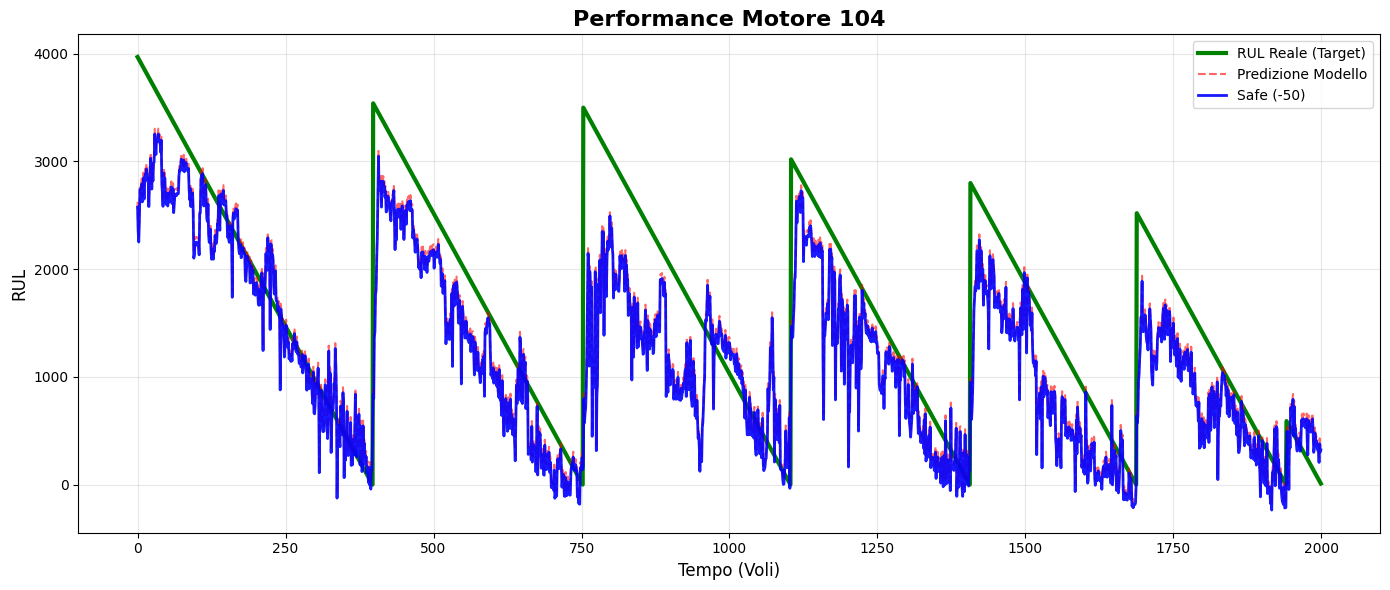

   Fold 2: RMSE=415 | Score=11.2354
   Fold 3: RMSE=860 | Score=13.8631
   Fold 4: RMSE=589 | Score=10.5058
   [MEDIA HPT] RMSE: 627.02 | SCORE: 12.0597

>>> HPC (Alpha: 0.15 | Margin: -50) <<<
   Fold 1: RMSE=2017 | Score=17.3006
   [Grafico] ESN 104...


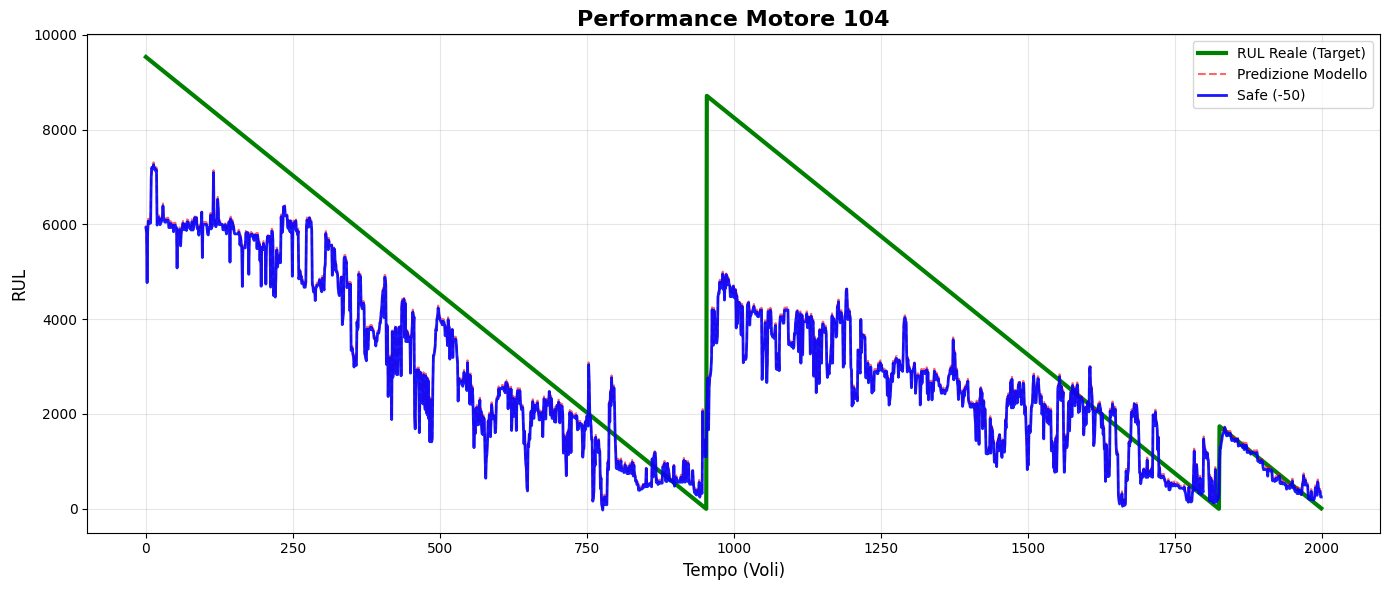

   Fold 2: RMSE=1669 | Score=12.3474
   Fold 3: RMSE=1218 | Score=11.3236
   Fold 4: RMSE=1158 | Score=7.3951
   [MEDIA HPC] RMSE: 1515.19 | SCORE: 12.0917

>>> WW (Alpha: 0.15 | Margin: -5) <<<
   Fold 1: RMSE=92 | Score=1.3851
   [Grafico] ESN 104...


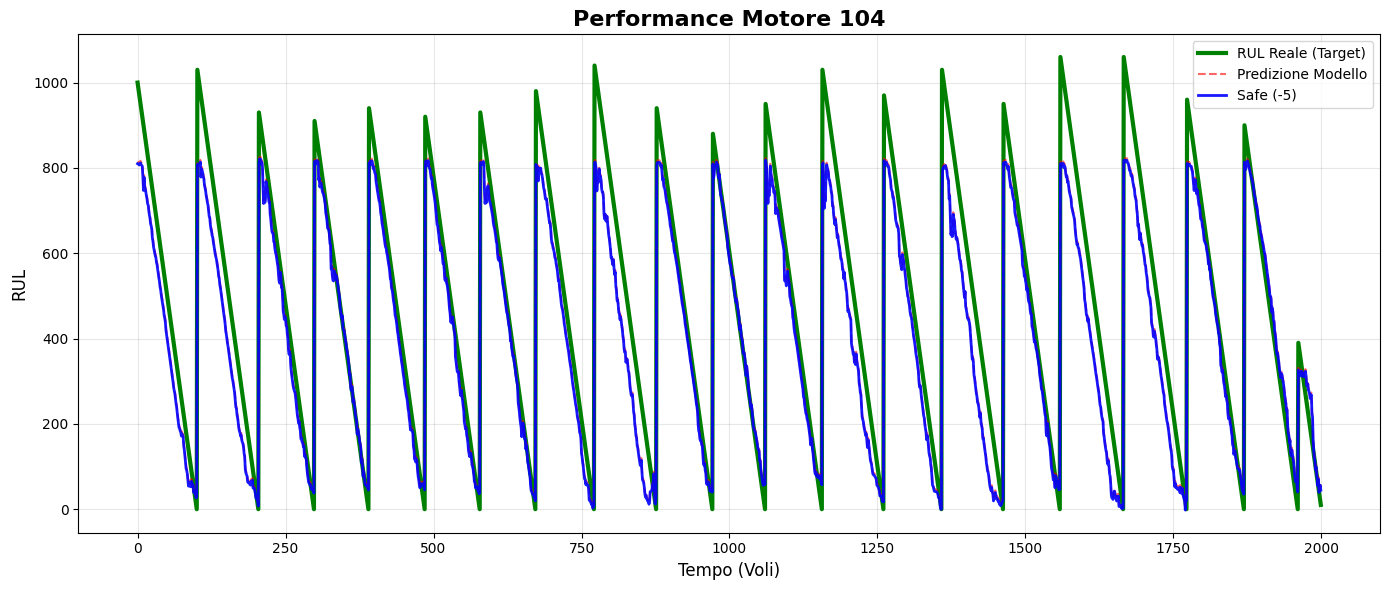

   Fold 2: RMSE=116 | Score=2.0513
   Fold 3: RMSE=124 | Score=2.3146
   Fold 4: RMSE=115 | Score=2.2801
   [MEDIA WW] RMSE: 111.72 | SCORE: 2.0078


In [9]:
#Gradient boosting, diviso i parametri tra HPT/HPC e WW, aggiunto i safe-margin, risultato score molto buoni

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import glob

def evaluate_on_folder(folder_path, models_dict, feature_sets):
    """
    Processa TUTTI i file CSV in una cartella.
    """
    # Trova tutti i CSV
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    if not all_files:
        print(f"Nessun file CSV trovato in {folder_path}")
        return

    print(f"\n--- VALIDAZIONE SU CARTELLA: {len(all_files)} file trovati ---")
    
    # Dizionario per accumulare i risultati globali (opzionale)
    global_results = {'HPT': [], 'HPC': [], 'WW': []}

    for file_path in sorted(all_files):
        filename = os.path.basename(file_path)
        print(f"\n>>> Processing: {filename}")
        
        try:
            df_test_raw = pd.read_csv(file_path)
        except Exception as e:
            print(f"Errore caricamento {filename}: {e}")
            continue

        # Se il file è vuoto o non valido, salta
        if df_test_raw.empty: continue

        # Identifica ESN per il titolo grafico
        current_esn = df_test_raw['ESN'].unique()[0] if 'ESN' in df_test_raw.columns else "Unknown"

        # Preprocessing separato
        df_mech_test = prepare_mechanical_data(df_test_raw)
        df_wash_test = prepare_wash_data(df_test_raw)
        
        data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
        
        # Loop sui 3 modelli (HPT, HPC, WW)
        for ctype, model_info in models_dict.items():
            model = model_info['model']
            margin = model_info['margin']
            target_name = model_info['target_name']
            
            df = data_map[ctype]
            
            # Se il file di test NON ha i target (è blind test), non calcoliamo score
            has_target = target_name in df.columns
            
            # Recupero features usate
            features = feature_sets[ctype]
            
            # Gestione colonne mancanti (riempi con 0)
            for f in features:
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            
            # Imputer veloce
            imputer = SimpleImputer(strategy='mean')
            X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
            
            # Predizione
            pred_raw = model.predict(X_test_clean)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            # Se abbiamo il target, calcoliamo Score e facciamo il Grafico
            if has_target:
                y_test = df[target_name]
                rmse = get_rmse(y_test, pred_safe)
                score = get_score(y_test, pred_safe, ctype)
                print(f"   [{ctype}] RMSE: {rmse:.0f} | Score: {score:.4f}")
                
                # Grafico
                if ctype == 'HPT': # Facciamo il grafico solo per HPT per non intasare, o cambia logica
                    # Plot dedicato per questo file/motore
                    plot_prediction_vs_rul(y_test, pred_raw, engine_id=f"{current_esn} ({ctype})", margin=margin)
            else:
                print(f"   [{ctype}] Predizione completata (No Target). RUL Safe medio: {np.mean(pred_safe):.0f}")

# ==============================================================================
# 0. FUNZIONE GRAFICA
# ==============================================================================
def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)
    plt.plot(y_pred, label='Predizione Modello', color='red', alpha=0.6, linestyle='--', linewidth=1.5)

    if margin > 0:
        plt.plot(y_pred_safe, label=f'Safe (-{margin})', color='blue', alpha=0.9, linewidth=2)

    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limit ({clip_limit})')

    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli)', fontsize=12)
    plt.ylabel('RUL', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def prepare_mechanical_data(df):
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    sensor_cols = [c for c in df.columns if 'Sensed_' in c]
    agg_dict = {col: 'mean' for col in sensor_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        for col in sensor_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
    return pd.DataFrame()

def prepare_wash_data(df):
    df = df.copy()
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    target_cols = ['Sensed_T45_res', 'Sensed_WFuel_res', 'Sensed_T3_res']
    use_cols = [c for c in target_cols if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max'

    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        new_cols = []
        feature_cols = []
        for c, s in df_grouped.columns:
            if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
            else: 
                name = f"{c}_{s}"
                new_cols.append(name)
                feature_cols.append(name)
        
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])

        # RESET CLOCK FEATURE
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
        
        for col in feature_cols:
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()

        df_grouped = df_grouped.ffill().bfill().fillna(0)
        
        drop_cols = ['WW_Change', 'Wash_Session_ID']
        df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
        
        return df_grouped
        
    return pd.DataFrame()

# ==============================================================================
# 2. METRICHE
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==============================================================================
# 3. FUNZIONE DI VALIDAZIONE ESTERNA
# ==============================================================================
def evaluate_on_test_file(file_path, models_dict, imputer_dict, features_dict):
    """
    Carica un file esterno, lo processa e valuta i modelli addestrati.
    """
    print(f"\n--- VALIDAZIONE SU FILE ESTERNO: {file_path} ---")
    try:
        df_test_raw = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {file_path} non trovato. Salto la validazione esterna.")
        return

    # Preprocessing separato
    df_mech_test = prepare_mechanical_data(df_test_raw)
    df_wash_test = prepare_wash_data(df_test_raw)
    
    # Mapping
    data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
    
    for ctype, model_info in models_dict.items():
        model = model_info['model']
        margin = model_info['margin']
        target_name = model_info['target_name']
        
        df = data_map[ctype]
        
        if target_name not in df.columns:
            print(f"Target {target_name} non trovato nel file di test. Impossibile valutare {ctype}.")
            continue
            
        # Recupero features usate in training
        features = features_dict[ctype]
        
        # Check se tutte le feature esistono
        missing_feats = [f for f in features if f not in df.columns]
        if missing_feats:
            print(f"Attenzione: {ctype} mancano feature nel test: {missing_feats[:3]}...")
            # Riempiamo con 0 per non crashare
            for f in missing_feats: df[f] = 0
            
        X_test = df[features]
        y_test = df[target_name]
        
        # Imputer (lo stesso usato in training o nuovo fit se semplice)
        # Qui usiamo un nuovo fit per semplicità, idealmente salveresti l'imputer
        imputer = SimpleImputer(strategy='mean')
        X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
        
        # Predizione
        pred_raw = model.predict(X_test_clean)
        pred_safe = np.maximum(pred_raw - margin, 0)
        
        # Metriche
        rmse = get_rmse(y_test, pred_safe)
        score = get_score(y_test, pred_safe, ctype)
        
        print(f">>> {ctype} TEST RESULTS:")
        print(f"   RMSE: {rmse:.2f}")
        print(f"   SCORE: {score:.4f}")
        
        # Plot del primo motore di test
        first_esn = df['ESN'].unique()[0]
        mask = df['ESN'] == first_esn
        plot_prediction_vs_rul(y_test[mask], pred_raw[mask], engine_id=f"TEST_{first_esn}", margin=margin)

# ==============================================================================
# 4. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except:
        print("File non trovato."); return

    print("\n--- DATASET ---")
    df_mech = prepare_mechanical_data(df_raw)
    df_wash = prepare_wash_data(df_raw)
    
    gkf = GroupKFold(n_splits=4)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.15, 'margin': 50}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.15, 'margin': 50},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 5}  
    ]

    # Dizionari per salvare i modelli finali per il test esterno
    trained_models = {}     
    feature_sets = {}

    print("\n--- AVVIO CROSS-VALIDATION ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features # Salviamo le feature usate
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        scores = []
        rmses = [] # Lista per RMSE
        
        print(f"\n>>> {ctype} (Alpha: {alpha_q} | Margin: -{margin}) <<<")
        
        # Parametri Dinamici
        if ctype == 'WW':
            n_est, max_d, lr = 100, 5, 0.05
        else:
            n_est, max_d, lr = 100, 2, 0.1

        # CV Loop
        for i, (train_idx, val_idx) in enumerate(gkf.split(X_clean, y, groups)):
            X_train, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            val_esn_series = groups.iloc[val_idx]
            
            model = GradientBoostingRegressor(
                loss='quantile', alpha=alpha_q, n_estimators=n_est, 
                learning_rate=lr, max_depth=max_d, random_state=42
            )
            model.fit(X_train, y_train)
            
            # Salviamo l'ultimo modello per il test esterno (approssimazione)
            if i == 0: 
                trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target}
            
            pred_raw = model.predict(X_val)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            score = get_score(y_val.values, pred_safe, ctype)
            rmse = get_rmse(y_val.values, pred_safe) # Calcolo RMSE
            
            scores.append(score)
            rmses.append(rmse)
            
            print(f"   Fold {i+1}: RMSE={rmse:.0f} | Score={score:.4f}")

            if i == 0: 
                viz_df = pd.DataFrame({'true': y_val.values, 'pred': pred_raw, 'ESN': val_esn_series.values})
                sample_esn = viz_df['ESN'].unique()[0]
                subset = viz_df[viz_df['ESN'] == sample_esn]
                print(f"   [Grafico] ESN {sample_esn}...")
                plot_prediction_vs_rul(subset['true'], subset['pred'], engine_id=sample_esn, margin=margin)

        print(f"   [MEDIA {ctype}] RMSE: {np.mean(rmses):.2f} | SCORE: {np.mean(scores):.4f}")

    # --- VALIDAZIONE SU CARTELLA ESTERNA ---
    #TEST_FOLDER_PATH = 'data/val/' # <--- La cartella con i tuoi 100 file
   # evaluate_on_folder(TEST_FOLDER_PATH, trained_models, feature_sets)

if __name__ == "__main__":
    main()

In [ ]:
# GAP ANALYSIS TRA TRAINING E VALIDATION

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 

# ==============================================================================
# 0. FUNZIONE GRAFICA
# ==============================================================================
def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)
    plt.plot(y_pred, label='Predizione Modello', color='red', alpha=0.6, linestyle='--', linewidth=1.5)

    if margin > 0:
        plt.plot(y_pred_safe, label=f'Safe (-{margin})', color='blue', alpha=0.9, linewidth=2)

    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limit ({clip_limit})')

    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli)', fontsize=12)
    plt.ylabel('RUL', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def harmonize_columns(df):
    rename_map = {'Cycles': 'Cycles_Since_New'}
    df = df.rename(columns=rename_map)
    return df

def prepare_mechanical_data(df):
    df = df.copy()
    df = harmonize_columns(df)
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # Ratios fisici per normalizzare
    if 'Sensed_T45' in df.columns and 'Sensed_T25' in df.columns:
        df['Ratio_T45_T25'] = df['Sensed_T45'] / df['Sensed_T25']
    if 'Sensed_Ps3' in df.columns and 'Sensed_Pt2' in df.columns:
        df['Ratio_Ps3_Pt2'] = df['Sensed_Ps3'] / df['Sensed_Pt2']

    raw_sensors = ['Sensed_T45', 'Sensed_Ps3', 'Sensed_T3', 'Sensed_Core_Speed']
    calc_sensors = ['Ratio_T45_T25', 'Ratio_Ps3_Pt2']
    use_cols = [c for c in raw_sensors + calc_sensors if c in df.columns]
    
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
    return pd.DataFrame()

def prepare_wash_data(df):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    if 'Sensed_WFuel' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Ratio_Fuel_Press'] = df['Sensed_WFuel'] / df['Sensed_Ps3']
    if 'Sensed_T45' in df.columns and 'Sensed_T25' in df.columns:
        df['Ratio_Temp_In_Out'] = df['Sensed_T45'] / df['Sensed_T25']
        
    target_cols = ['Ratio_Fuel_Press', 'Ratio_Temp_In_Out', 'Sensed_T45', 'Sensed_WFuel']
    use_cols = [c for c in target_cols if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    if 'Cumulative_WWs' in df.columns: agg_dict['Cumulative_WWs'] = 'max'

    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        new_cols = []
        feature_cols = []
        for c, s in df_grouped.columns:
            if c in ['Cycles_to_WW', 'Cumulative_WWs'] or s == '': new_cols.append(c)
            else: 
                name = f"{c}_{s}"
                new_cols.append(name)
                feature_cols.append(name)
        
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])

        # Reset Clock Feature
        if 'Cumulative_WWs' in df_grouped.columns:
             df_grouped['WW_Change'] = df_grouped.groupby('ESN')['Cumulative_WWs'].diff().fillna(0)
             df_grouped['Wash_Session_ID'] = df_grouped.groupby('ESN')['WW_Change'].cumsum()
             df_grouped['Cycles_Since_Last_Wash'] = df_grouped.groupby(['ESN', 'Wash_Session_ID']).cumcount()
        
        for col in feature_cols:
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()

        df_grouped = df_grouped.ffill().bfill().fillna(0)
        drop_cols = ['WW_Change', 'Wash_Session_ID']
        df_grouped = df_grouped.drop(columns=[c for c in drop_cols if c in df_grouped.columns])
        return df_grouped
    return pd.DataFrame()

# ==============================================================================
# 2. METRICHE
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==============================================================================
# 3. DIAGNOSI GAP ANALYSIS (NUOVA FUNZIONE)
# ==============================================================================
def diagnose_gap_analysis(X, y, groups, model_params, margin, ctype):
    """
    Esegue una Cross-Validation interna per confrontare lo Score su Train vs Validation.
    Serve a capire se stiamo facendo Overfitting.
    """
    print(f"\n" + "="*50)
    print(f" DIAGNOSI GAP (Overfitting Check): {ctype}")
    print("="*50)

    gkf = GroupKFold(n_splits=4)
    train_scores = []
    val_scores = []
    
    # Parametri modello
    alpha_q = model_params['alpha']
    n_est = model_params['n_estimators']
    lr = model_params['learning_rate']
    max_d = model_params['max_depth']
    subs = model_params['subsample']

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        # 1. Addestramento (Stesso modello usato nel main)
        model = GradientBoostingRegressor(
            loss='quantile', alpha=alpha_q, 
            n_estimators=n_est, learning_rate=lr, max_depth=max_d,
            subsample= subs, 
            random_state=42
        )
        model.fit(X_train, y_train)

        # 2. Predizione Train (Memoria) vs Val (Realtà)
        pred_train_raw = model.predict(X_train)
        pred_val_raw = model.predict(X_val)
        
        # Applichiamo lo stesso margine di sicurezza
        pred_train_safe = np.maximum(pred_train_raw - margin, 0)
        pred_val_safe = np.maximum(pred_val_raw - margin, 0)

        # 3. Calcolo Score
        score_train = get_score(y_train.values, pred_train_safe, ctype)
        score_val = get_score(y_val.values, pred_val_safe, ctype)
        
        train_scores.append(score_train)
        val_scores.append(score_val)

        # 4. Analisi Gap
        gap = score_val - score_train
        
        # Logica Semaforo (basata sulla differenza di score)
        # Nota: In PHM score basso è meglio. Se Val >> Train, è male.
        if gap < 5: status = "🟢 OTTIMO (Robusto)"
        elif gap < 10: status = "🟡 OK (Accettabile)"
        else: status = "🔴 ATTENZIONE (Possibile Overfitting)"
        
        print(f"Fold {fold+1}: Train Score={score_train:.2f} | Val Score={score_val:.2f} | GAP={gap:.2f} -> {status}")

    avg_train = np.mean(train_scores)
    avg_val = np.mean(val_scores)
    
    print("-" * 30)
    print(f"MEDIA {ctype}:")
    print(f"  Train Score: {avg_train:.2f}")
    print(f"  Val Score:   {avg_val:.2f}")
    print(f"  GAP MEDIO:   {avg_val - avg_train:.2f}")
    print("-" * 30 + "\n")

# ==============================================================================
# 4. VALUTAZIONE SU CARTELLA ESTERNA
# ==============================================================================
def evaluate_on_folder(folder_path, models_dict, feature_sets):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    if not all_files:
        print(f"Nessun file CSV trovato in {folder_path}")
        return

    print(f"\n--- VALIDAZIONE DETTAGLIATA SU CARTELLA ({len(all_files)} files) ---")
    
    for file_path in sorted(all_files):
        filename = os.path.basename(file_path)
        try:
            df_test_raw = pd.read_csv(file_path)
        except: continue
            
        if df_test_raw.empty: continue
        df_test_raw = harmonize_columns(df_test_raw)
        
        df_mech_test = prepare_mechanical_data(df_test_raw)
        df_wash_test = prepare_wash_data(df_test_raw)
        data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
        
        for ctype, model_info in models_dict.items():
            model = model_info['model']
            margin = model_info['margin']
            target_name = model_info['target_name']
            
            df = data_map[ctype]
            if df.empty: continue

            features = feature_sets[ctype]
            for f in features:
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            imputer = SimpleImputer(strategy='mean')
            try:
                X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
            except: continue
            
            pred_raw = model.predict(X_test_clean)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            if target_name in df.columns:
                y_test = df[target_name]
                score = get_score(y_test, pred_safe, ctype)
                print(f"   [{filename} - {ctype}] SCORE: {score:.4f}")

# ==============================================================================
# 5. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw)

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw)
    df_wash = prepare_wash_data(df_raw)
    
    # Configurazione Modelli e Margini
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.15, 'margin': 50}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.15, 'margin': 50},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 5}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n--- AVVIO ANALISI E TRAINING ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        # Setup Parametri
        if ctype == 'WW':
            params = {'n_estimators': 100,
                      'max_depth': 3,
                      'learning_rate': 0.05,
                      'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 100,
                      'max_depth': 2,
                      'learning_rate': 0.05,
                      'alpha': alpha_q,
                      'subsample': 1.0}

        diagnose_gap_analysis(X_clean, y, groups, params, margin, ctype)

        print(f">>> Training finale Modello {ctype} su tutto il dataset...")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target}
        print("    Fatto.\n")

    # --- VALIDAZIONE SU CARTELLA ESTERNA ---
    TEST_FOLDER_PATH = 'data/val/'  
    evaluate_on_folder(TEST_FOLDER_PATH, trained_models, feature_sets)

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING ---

--- DATASET PREPARATION ---

--- AVVIO ANALISI E TRAINING ---

 DIAGNOSI GAP (Overfitting Check): HPT
Fold 1: Train Score=23.06 | Val Score=29.33 | GAP=6.28 -> 🟡 OK (Accettabile)
Fold 2: Train Score=23.66 | Val Score=33.10 | GAP=9.43 -> 🟡 OK (Accettabile)
Fold 3: Train Score=25.95 | Val Score=32.62 | GAP=6.67 -> 🟡 OK (Accettabile)
Fold 4: Train Score=25.22 | Val Score=25.07 | GAP=-0.15 -> 🟢 OTTIMO (Robusto)
------------------------------
MEDIA HPT:
  Train Score: 24.47
  Val Score:   30.03
  GAP MEDIO:   5.56
------------------------------

>>> Training finale Modello HPT su tutto il dataset...
    Fatto.


 DIAGNOSI GAP (Overfitting Check): HPC
Fold 1: Train Score=26.91 | Val Score=36.90 | GAP=9.99 -> 🟡 OK (Accettabile)
Fold 2: Train Score=28.94 | Val Score=36.25 | GAP=7.30 -> 🟡 OK (Accettabile)
Fold 3: Train Score=21.20 | Val Score=49.33 | GAP=28.13 -> 🔴 ATTENZIONE (Possibile Overfitting)
Fold 4: Train Score=27.04 | Val Score=29.78 | GAP=2.74 -> 🟢 OTTIMO

In [12]:
#nuovo test con colonne del validation aggiustate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 

# ==============================================================================
# 0. FUNZIONI DI UTILITÀ
# ==============================================================================
def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)
    plt.plot(y_pred, label='Predizione Modello', color='red', alpha=0.6, linestyle='--', linewidth=1.5)
    if margin > 0:
        plt.plot(y_pred_safe, label=f'Safe (-{margin})', color='blue', alpha=0.9, linewidth=2)
    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli)', fontsize=12)
    plt.ylabel('RUL', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def harmonize_columns(df):
    """
    Rinomina le colonne del validation per renderle uguali al train.
    """
    rename_map = {
        'Cycles': 'Cycles_Since_New', # <--- FIX PRINCIPALE
        'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude',
        'Mach': 'Sensed_Mach'
    }
    df = df.rename(columns=rename_map)
    return df

# ==============================================================================
# 1. PREPROCESSING (SOLO FEATURE COMUNI)
# ==============================================================================
def prepare_mechanical_data(df):
    """Pipeline HPT/HPC: Usa solo sensori presenti in TRAIN e VAL."""
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # --- FEATURE ENGINEERING ROBUSTO ---
    # Usiamo solo colonne sicure (presenti nella tua lista VAL)
    # Train ha T5 e P25, ma Val NO. Quindi NON LI USIAMO neanche in training.
    
    # Ratios (Sostituiscono i residui)
    if 'Sensed_T45' in df.columns and 'Sensed_T25' in df.columns:
        df['Ratio_T45_T25'] = df['Sensed_T45'] / df['Sensed_T25']
        
    if 'Sensed_Ps3' in df.columns and 'Sensed_Pt2' in df.columns:
        df['Ratio_Ps3_Pt2'] = df['Sensed_Ps3'] / df['Sensed_Pt2']

    # LISTA SICURA (Check your VAL columns list)
    # Val columns: Altitude, Mach, Pamb, Pt2, TAT, WFuel, VAFN, VBV, Fan, Core, T25, T3, Ps3, T45
    raw_sensors = ['Sensed_T45', 'Sensed_Ps3', 'Sensed_T3', 'Sensed_Core_Speed', 'Sensed_WFuel']
    calc_sensors = ['Ratio_T45_T25', 'Ratio_Ps3_Pt2']
    
    use_cols = [c for c in raw_sensors + calc_sensors if c in df.columns]
    
    # Aggregazione
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        
        # Smoothing
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
        
    return pd.DataFrame()

def prepare_wash_data(df):
    """Pipeline WW: Adattata per colonne mancanti (Niente T5, niente Cumulative)"""
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    # --- FEATURE ENGINEERING WW ---
    # Non avendo T5, usiamo T45 come proxy principale per la temperatura EGT
    if 'Sensed_WFuel' in df.columns and 'Sensed_Ps3' in df.columns:
        df['Ratio_Fuel_Press'] = df['Sensed_WFuel'] / df['Sensed_Ps3']
    
    # Usiamo T45 invece di T5 (perché T5 manca nel val)
    if 'Sensed_T45' in df.columns and 'Sensed_T25' in df.columns:
        df['Ratio_Temp_In_Out'] = df['Sensed_T45'] / df['Sensed_T25']
        
    # Colonne Target per l'analisi
    target_cols = ['Ratio_Fuel_Press', 'Ratio_Temp_In_Out', 'Sensed_T45', 'Sensed_WFuel']
    use_cols = [c for c in target_cols if c in df.columns]
    
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    
    # NOTA: Rimosso Cumulative_WWs perché non c'è nel Validation Set
    
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        new_cols = []
        feature_cols = []
        for c, s in df_grouped.columns:
            if c == 'Cycles_to_WW' or s == '': new_cols.append(c)
            else: 
                name = f"{c}_{s}"
                new_cols.append(name)
                feature_cols.append(name)
        
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])

        # Feature Engineering (Lags e Gradienti)
        for col in feature_cols:
            # Lags (Memoria breve)
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            
            # Smoothing leggero
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            # Gradiente
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()

        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
        
    return pd.DataFrame()

# ==============================================================================
# 2. METRICHE
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==============================================================================
# 3. DIAGNOSI GAP ANALYSIS
# ==============================================================================
def diagnose_gap_analysis(X, y, groups, model_params, margin, ctype):
    print(f"\n" + "="*50)
    print(f" DIAGNOSI GAP (Overfitting Check): {ctype}")
    print("="*50)

    gkf = GroupKFold(n_splits=4)
    train_scores, val_scores = [], []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = GradientBoostingRegressor(
            loss='quantile', alpha=model_params['alpha'], 
            n_estimators=model_params['n_estimators'], 
            learning_rate=model_params['learning_rate'], 
            max_depth=model_params['max_depth'], 
            subsample=model_params['subsample'],
            random_state=42
        )
        model.fit(X_train, y_train)

        pred_train_safe = np.maximum(model.predict(X_train) - margin, 0)
        pred_val_safe = np.maximum(model.predict(X_val) - margin, 0)

        score_train = get_score(y_train.values, pred_train_safe, ctype)
        score_val = get_score(y_val.values, pred_val_safe, ctype)
        
        train_scores.append(score_train)
        val_scores.append(score_val)

        gap = score_val - score_train
        if gap < 2: status = "🟢 OTTIMO"
        elif gap < 5: status = "🟡 OK"
        else: status = "🔴 ATTENZIONE"
        
        print(f"Fold {fold+1}: Train={score_train:.2f} | Val={score_val:.2f} | GAP={gap:.2f} -> {status}")

    print(f"MEDIA {ctype}: Train={np.mean(train_scores):.2f} | Val={np.mean(val_scores):.2f} | GAP={np.mean(val_scores)-np.mean(train_scores):.2f}")

# ==============================================================================
# 4. VALUTAZIONE SU CARTELLA ESTERNA
# ==============================================================================
def evaluate_on_folder(folder_path, models_dict, feature_sets):
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    if not all_files:
        print(f"Nessun file CSV trovato in {folder_path}")
        return

    print(f"\n--- VALIDAZIONE DETTAGLIATA SU CARTELLA ({len(all_files)} files) ---")
    
    for file_path in sorted(all_files):
        filename = os.path.basename(file_path)
        try:
            df_test_raw = pd.read_csv(file_path)
        except: continue
            
        if df_test_raw.empty: continue
        
        # FIX COLONNE (Cycles -> Cycles_Since_New)
        df_test_raw = harmonize_columns(df_test_raw)
        
        # Recupera ESN
        current_esn = df_test_raw['ESN'].unique()[0] if 'ESN' in df_test_raw.columns else "Unknown"
        
        # Preprocessing
        df_mech_test = prepare_mechanical_data(df_test_raw)
        df_wash_test = prepare_wash_data(df_test_raw)
        
        data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
        
        print(f"\n>>> File: {filename} (Motore {current_esn})")
        found_pred = False

        for ctype, model_info in models_dict.items():
            model = model_info['model']
            margin = model_info['margin']
            target_name = model_info['target_name']
            
            df = data_map[ctype]
            if df.empty: continue

            features = feature_sets[ctype]
            
            # Gestione colonne mancanti (IMPORTANTE: Mette a 0 quelle che mancano)
            for f in features:
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            
            try:
                imputer = SimpleImputer(strategy='mean')
                X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
            except: continue
            
            pred_raw = model.predict(X_test_clean)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            avg_rul = np.mean(pred_safe)
            
            if target_name in df.columns:
                y_test = df[target_name]
                score = get_score(y_test, pred_safe, ctype)
                print(f"   [{ctype}] SCORE: {score:.4f} | RMSE: {get_rmse(y_test, pred_safe):.1f}")
            else:
                # Se è blind test, stampiamo la media
                print(f"   [{ctype}] Predizione (Blind): {avg_rul:.0f} cicli")
            found_pred = True
            
        if not found_pred:
            print("   [WARNING] Nessun dato valido (filtri troppo stretti?)")

def generate_submission_file(folder_path, models_dict, feature_sets, output_file='submission.csv'):
    """
    Genera il file CSV finale con le predizioni.
    Formato: filename, HPT_pred, HPC_pred, WW_pred
    """
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    results = []
    
    print(f"\n--- GENERAZIONE SUBMISSION FILE ({len(all_files)} files) ---")
    
    for file_path in sorted(all_files):
        filename = os.path.basename(file_path)
        
        try:
            df_test_raw = pd.read_csv(file_path)
        except: continue
        if df_test_raw.empty: continue
        
        # Preprocessing & Fix
        df_test_raw = harmonize_columns(df_test_raw)
        df_mech = prepare_mechanical_data(df_test_raw)
        df_wash = prepare_wash_data(df_test_raw)
        
        data_map = {'HPT': df_mech, 'HPC': df_mech, 'WW': df_wash}
        
        # Dizionario per salvare le predizioni di questo file
        row_pred = {'File_ID': filename}
        
        for ctype in ['HPT', 'HPC', 'WW']:
            model = models_dict[ctype]['model']
            margin = models_dict[ctype]['margin']
            
            df = data_map[ctype]
            features = feature_sets[ctype]
            
            # Gestione colonne mancanti
            for f in features: 
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            imputer = SimpleImputer(strategy='mean')
            try:
                X_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
                pred_raw = model.predict(X_clean)
                pred_safe = np.maximum(pred_raw - margin, 0)
                
                # Prendiamo l'ULTIMO valore predetto come RUL del file
                # (Oppure la media, dipende dalle regole. Di solito è l'ultimo punto)
                final_val = pred_safe[-1] if len(pred_safe) > 0 else 0
                
                row_pred[ctype] = final_val
            except:
                row_pred[ctype] = 0 # Fallback
                
        results.append(row_pred)
        
    # Salvataggio
    df_submission = pd.DataFrame(results)
    df_submission.to_csv(output_file, index=False)
    print(f"File salvato: {output_file}")
    print(df_submission.head())


# 5. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except:
        print("File non trovato."); return
    
    df_raw = harmonize_columns(df_raw) # Standardizziamo anche il train

    print("\n--- DATASET PREPARATION ---")
    df_mech = prepare_mechanical_data(df_raw)
    df_wash = prepare_wash_data(df_raw)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.15, 'margin': 50}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.15, 'margin': 50},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 5}  
    ]

    trained_models = {}     
    feature_sets = {}

    print("\n--- AVVIO ANALISI E TRAINING ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features 
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        # Parametri Anti-Overfitting
        if ctype == 'WW':
            params = {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 1.0}
        else:
            params = {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'alpha': alpha_q, 'subsample': 0.7}

        # 1. Diagnosi (Opzionale, decommenta se vuoi vederla ancora)
        # diagnose_gap_analysis(X_clean, y, groups, params, margin, ctype)

        # 2. Training Finale
        print(f">>> Training finale Modello {ctype}...")
        model = GradientBoostingRegressor(
            loss='quantile', alpha=params['alpha'], 
            n_estimators=params['n_estimators'], 
            learning_rate=params['learning_rate'], 
            max_depth=params['max_depth'], 
            subsample=params['subsample'],
            random_state=42
        )
        model.fit(X_clean, y)
        
        trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target}
        print("    Fatto.")

    # --- VALIDAZIONE SU CARTELLA ESTERNA ---
    TEST_FOLDER_PATH = 'data/val/'  
    evaluate_on_folder(TEST_FOLDER_PATH, trained_models, feature_sets)
    generate_submission_file(TEST_FOLDER_PATH, trained_models, feature_sets)

if __name__ == "__main__":
    main()

--- CARICAMENTO TRAINING ---

--- DATASET PREPARATION ---

--- AVVIO ANALISI E TRAINING ---
>>> Training finale Modello HPT...
    Fatto.
>>> Training finale Modello HPC...
    Fatto.
>>> Training finale Modello WW...
    Fatto.

--- VALIDAZIONE DETTAGLIATA SU CARTELLA (48 files) ---

>>> File: val_0.csv (Motore 107)
   [HPT] Predizione (Blind): 1411 cicli
   [HPC] Predizione (Blind): 5290 cicli
   [WW] Predizione (Blind): 482 cicli

>>> File: val_1.csv (Motore 108)
   [HPT] Predizione (Blind): 1484 cicli
   [HPC] Predizione (Blind): 5443 cicli
   [WW] Predizione (Blind): 500 cicli

>>> File: val_10.csv (Motore 113)
   [HPT] Predizione (Blind): 1473 cicli
   [HPC] Predizione (Blind): 6635 cicli
   [WW] Predizione (Blind): 511 cicli

>>> File: val_11.csv (Motore 113)
   [HPT] Predizione (Blind): 1538 cicli
   [HPC] Predizione (Blind): 6620 cicli
   [WW] Predizione (Blind): 514 cicli

>>> File: val_12.csv (Motore 108)
   [HPT] Predizione (Blind): 1939 cicli
   [HPC] Predizione (Blind): 5

--- CARICAMENTO TRAINING ---

--- DATASET ---

--- AVVIO CROSS-VALIDATION ---

>>> HPT (Alpha: 0.15 | Margin: -50) <<<
   Fold 1: RMSE=652 | Score=30.9457
   [Grafico] ESN 104...


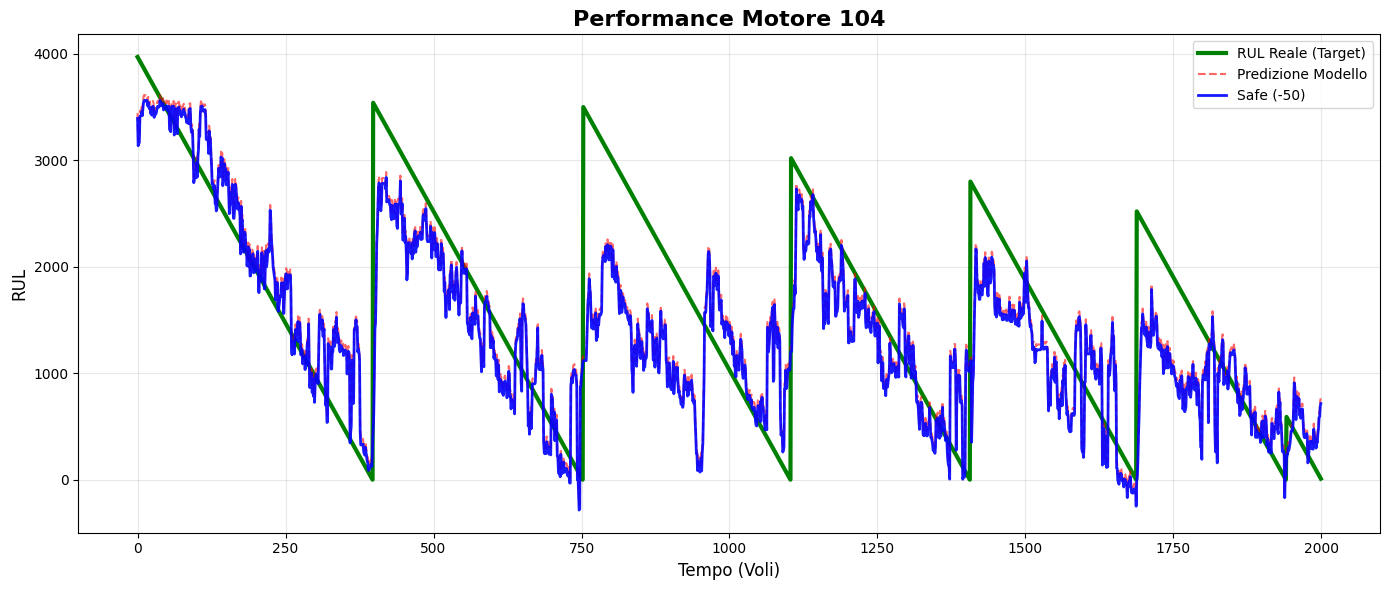

   Fold 2: RMSE=664 | Score=13.9515
   Fold 3: RMSE=1103 | Score=20.2180
   Fold 4: RMSE=762 | Score=15.1319
   [MEDIA HPT] RMSE: 795.25 | SCORE: 20.0618

>>> HPC (Alpha: 0.15 | Margin: -50) <<<
   Fold 1: RMSE=2720 | Score=39.9705
   [Grafico] ESN 104...


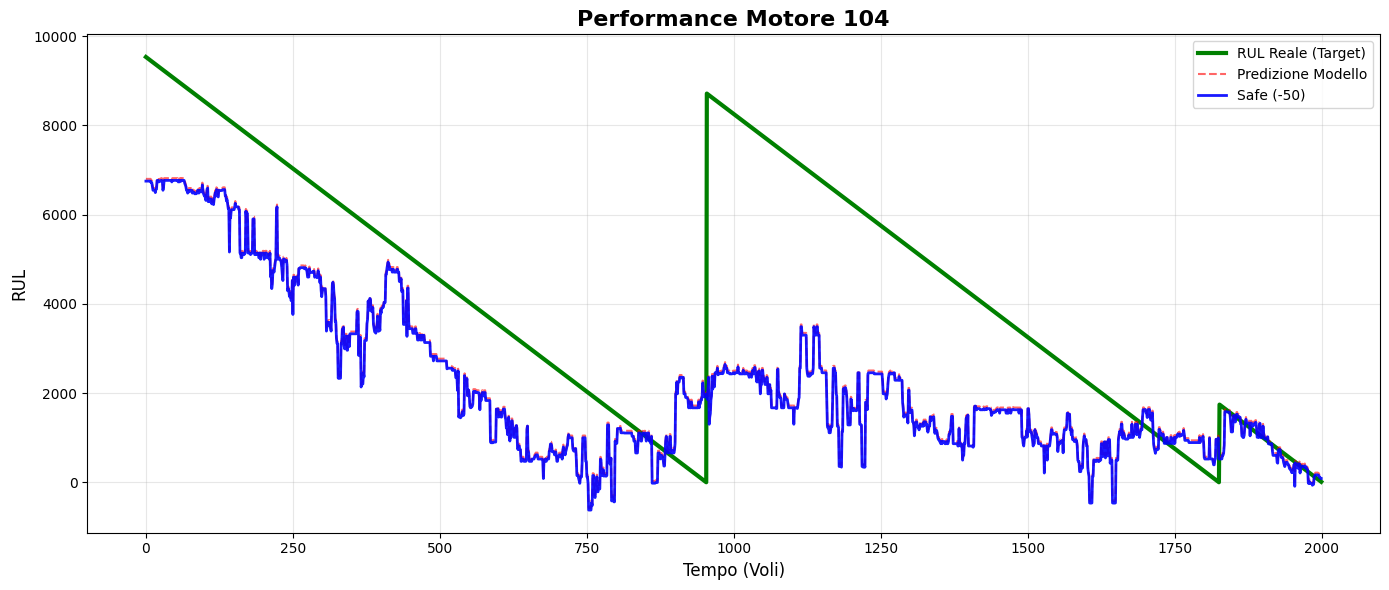

   Fold 2: RMSE=2366 | Score=24.0715
   Fold 3: RMSE=2116 | Score=53.6903
   Fold 4: RMSE=2230 | Score=29.0794
   [MEDIA HPC] RMSE: 2357.67 | SCORE: 36.7029

>>> WW (Alpha: 0.15 | Margin: -5) <<<
   Fold 1: RMSE=401 | Score=21.7825
   [Grafico] ESN 104...


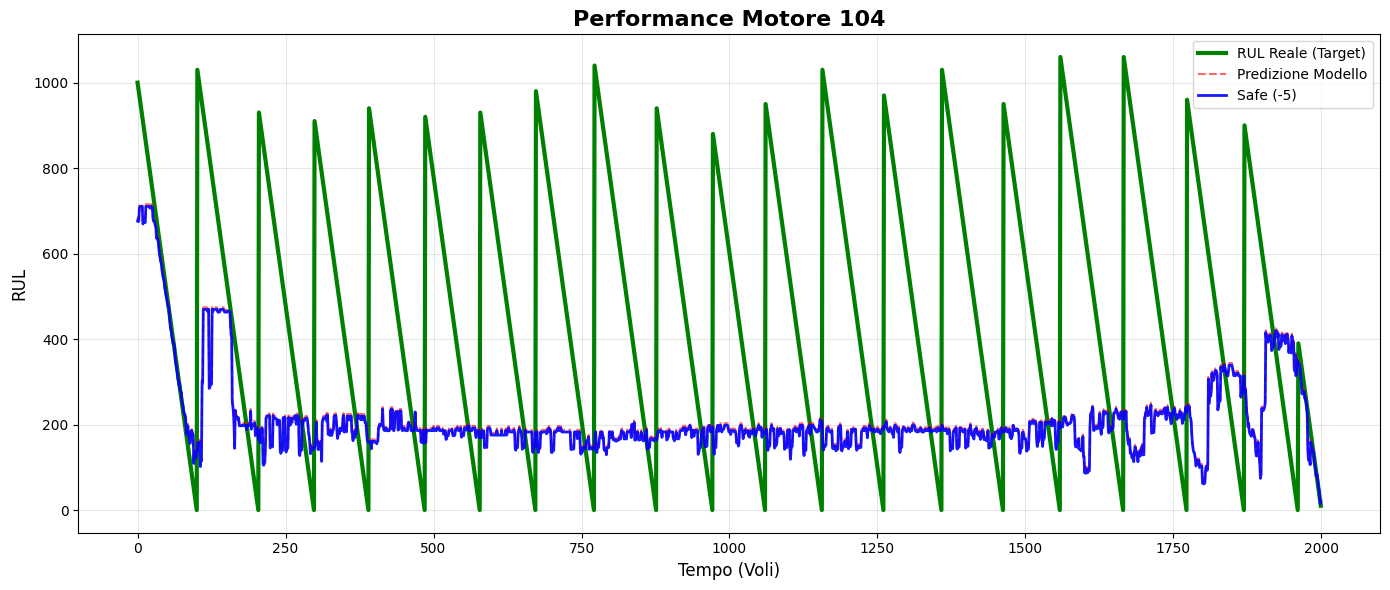

   Fold 2: RMSE=431 | Score=20.9129
   Fold 3: RMSE=435 | Score=21.3817
   Fold 4: RMSE=455 | Score=22.5289
   [MEDIA WW] RMSE: 430.47 | SCORE: 21.6515


In [5]:
#Gradient boosting, diviso i parametri tra HPT/HPC e WW, aggiunto i safe-margin, risultato score molto buoni
# e aggiungo le leggi fisiche

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer 
import glob

def harmonize_columns(df):
    """
    Rinomina le colonne del validation per renderle uguali al train.
    Gestisce varianti di nomi comuni nei dataset aeronautici.
    """
    # Mappa delle possibili varianti -> Nome Standard (Training)
    rename_map = {
        'Cycles': 'Cycles_Since_New', 
        'Cycle': 'Cycles_Since_New',
        'Altitude': 'Sensed_Altitude',
        'Alt': 'Sensed_Altitude',
        'Mach': 'Sensed_Mach',
        'TRA': 'Sensed_TRA',
        'T2': 'Sensed_T2',
        'T24': 'Sensed_T24',
        'T30': 'Sensed_T3',
        'T48': 'Sensed_T45',
        'T50': 'Sensed_T5',
        'P15': 'Sensed_P15',
        'P2': 'Sensed_P2',
        'P21': 'Sensed_P21',
        'P24': 'Sensed_P24',
        'Ps30': 'Sensed_Ps3',
        'P40': 'Sensed_P40',
        'P50': 'Sensed_P50',
        'HPC_SV': 'Cycles_to_HPC_SV',
        'HPT_SV': 'Cycles_to_HPT_SV',
        'WW': 'Cycles_to_WW'
    }
    
    # Rinomina le colonne che trova
    df = df.rename(columns=rename_map)
    
    # Fallback: Se mancano i prefissi "Sensed_" e non abbiamo rinominato nulla di critico
    # prova ad aggiungere "Sensed_" a tutte le colonne numeriche rimanenti
    if 'Sensed_Altitude' not in df.columns and 'Altitude' not in df.columns:
         for col in df.columns:
             if col not in ['ESN', 'Cycles_Since_New', 'Snapshot', 'File_ID']:
                 if not col.startswith('Sensed_') and not col.startswith('Phy_'):
                     df.rename(columns={col: f'Sensed_{col}'}, inplace=True)
                     
    return df

def evaluate_on_folder(folder_path, models_dict, feature_sets):
    """
    Processa TUTTI i file CSV in una cartella.
    """
    # Trova tutti i CSV
    search_path = os.path.join(folder_path, "*.csv")
    all_files = glob.glob(search_path)
    
    if not all_files:
        print(f"Nessun file CSV trovato in {folder_path}")
        return

    print(f"\n--- VALIDAZIONE SU CARTELLA: {len(all_files)} file trovati ---")
    
    # Dizionario per accumulare i risultati globali (opzionale)
    global_results = {'HPT': [], 'HPC': [], 'WW': []}

    for file_path in sorted(all_files):
        filename = os.path.basename(file_path)
        print(f"\n>>> Processing: {filename}")
        
        try:
            df_test_raw = pd.read_csv(file_path)
        except Exception as e:
            print(f"Errore caricamento {filename}: {e}")
            continue

        # Se il file è vuoto o non valido, salta
        if df_test_raw.empty: continue

        # Identifica ESN per il titolo grafico
        current_esn = df_test_raw['ESN'].unique()[0] if 'ESN' in df_test_raw.columns else "Unknown"

        # Preprocessing separato
        df_mech_test = prepare_mechanical_data(df_test_raw)
        df_wash_test = prepare_wash_data(df_test_raw)
        
        data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
        
        # Loop sui 3 modelli (HPT, HPC, WW)
        for ctype, model_info in models_dict.items():
            model = model_info['model']
            margin = model_info['margin']
            target_name = model_info['target_name']
            
            df = data_map[ctype]
            
            # Se il file di test NON ha i target (è blind test), non calcoliamo score
            has_target = target_name in df.columns
            
            # Recupero features usate
            features = feature_sets[ctype]
            
            # Gestione colonne mancanti (riempi con 0)
            for f in features:
                if f not in df.columns: df[f] = 0
            
            X_test = df[features]
            
            # Imputer veloce
            imputer = SimpleImputer(strategy='mean')
            X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
            
            # Predizione
            pred_raw = model.predict(X_test_clean)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            # Se abbiamo il target, calcoliamo Score e facciamo il Grafico
            if has_target:
                y_test = df[target_name]
                rmse = get_rmse(y_test, pred_safe)
                score = get_score(y_test, pred_safe, ctype)
                print(f"   [{ctype}] RMSE: {rmse:.0f} | Score: {score:.4f}")
                
                # Grafico
                if ctype == 'HPT': # Facciamo il grafico solo per HPT per non intasare, o cambia logica
                    # Plot dedicato per questo file/motore
                    plot_prediction_vs_rul(y_test, pred_raw, engine_id=f"{current_esn} ({ctype})", margin=margin)
            else:
                print(f"   [{ctype}] Predizione completata (No Target). RUL Safe medio: {np.mean(pred_safe):.0f}")

# ==============================================================================
# 0. FUNZIONE GRAFICA
# ==============================================================================
def plot_prediction_vs_rul(y_true, y_pred, engine_id="N/A", margin=0, clip_limit=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred_safe = y_pred - margin

    plt.figure(figsize=(14, 6))
    plt.plot(y_true, label='RUL Reale (Target)', color='green', linewidth=3)
    plt.plot(y_pred, label='Predizione Modello', color='red', alpha=0.6, linestyle='--', linewidth=1.5)

    if margin > 0:
        plt.plot(y_pred_safe, label=f'Safe (-{margin})', color='blue', alpha=0.9, linewidth=2)

    if clip_limit:
        plt.axhline(clip_limit, color='gray', linestyle=':', label=f'Limit ({clip_limit})')

    plt.title(f'Performance Motore {engine_id}', fontsize=16, fontweight='bold')
    plt.xlabel('Tempo (Voli)', fontsize=12)
    plt.ylabel('RUL', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. PREPROCESSING
# ==============================================================================
def add_physics_features(df):
    """
    Arricchisce il dataframe con feature basate sulle leggi della termodinamica.
    Funziona solo se le colonne necessarie sono presenti.
    """
    df = df.copy()
    
    # Costanti Fisiche
    GAMMA_AIR = 1.4       # Indice adiabatico aria (Compressore)
    GAMMA_GAS = 1.33      # Indice adiabatico gas combusti (Turbina)
    STD_TEMP = 288.15     # Kelvin (15°C - Livello del mare)
    STD_PRES = 14.696     # PSI (1 atm - Livello del mare)

    # ---------------------------------------------------------
    # 1. PARAMETRI CORRETTI (Corrected Parameters)
    # Legge Fisica: Normalizza le condizioni ambientali (Theta e Delta)
    # ---------------------------------------------------------
    # Usiamo T25 e Pt2 come proxy delle condizioni di ingresso (Theta/Delta)
    if 'Sensed_T25' in df.columns and 'Sensed_Pt2' in df.columns:
        # Theta = T_ingresso / T_std
        theta = (df['Sensed_T25'] + 273.15) / STD_TEMP 
        # Delta = P_ingresso / P_std
        delta = df['Sensed_Pt2'] / STD_PRES
        
        # Evitiamo divisioni per zero
        theta = theta.replace(0, 1)
        delta = delta.replace(0, 1)

        # Core Speed Corretta (N2_Corr)
        if 'Sensed_Core_Speed' in df.columns:
            df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)

        # Fuel Flow Corretto (Wf_Corr)
        if 'Sensed_WFuel' in df.columns:
            df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))

        # EGT Corretta (T45_Corr)
        if 'Sensed_T45' in df.columns:
            df['Phy_T45_Corr'] = (df['Sensed_T45'] + 273.15) / theta

    # ---------------------------------------------------------
    # 2. EFFICIENZA ISENTROPICA COMPRESSORE (Isentropic Efficiency)
    # Legge Fisica: (T_ideale - T_in) / (T_reale - T_in)
    # ---------------------------------------------------------
    # Richiede: T25 (in), T3 (out), Pt2 (in), Ps3 (out)
    req_cols = ['Sensed_T25', 'Sensed_T3', 'Sensed_Pt2', 'Sensed_Ps3']
    if all(c in df.columns for c in req_cols):
        T_in_K = df['Sensed_T25'] + 273.15
        T_out_K = df['Sensed_T3'] + 273.15
        P_in = df['Sensed_Pt2']
        P_out = df['Sensed_Ps3']
        
        # Rapporto di Compressione
        pr = P_out / P_in
        
        # Temperatura Ideale (Isentropica) se il compressore fosse perfetto
        # Formula: T_iso = T_in * (PR ^ ((gamma-1)/gamma))
        k = (GAMMA_AIR - 1) / GAMMA_AIR
        T_iso = T_in_K * (pr ** k)
        
        # Efficienza = Lavoro Ideale / Lavoro Reale
        # Se il compressore è rotto/sporco, T_out_K aumenta e l'efficienza CROLLA.
        df['Phy_Compressor_Eff'] = (T_iso - T_in_K) / (T_out_K - T_in_K)

    # ---------------------------------------------------------
    # 3. HEAT RATE / ENERGY CONVERSION
    # Legge Fisica: Quanto calore (T45) genero per ogni unità di pressione (Ps3)?
    # ---------------------------------------------------------
    if 'Sensed_T45' in df.columns and 'Sensed_Ps3' in df.columns:
        # Un motore sano genera tanta pressione con poco calore.
        # Un motore rotto genera tanto calore e poca pressione.
        df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

def prepare_mechanical_data(df):
    df = df.copy()
    df = harmonize_columns(df) # Sempre per primo
    
    if 'Sensed_Altitude' in df.columns:
        df = df[df['Sensed_Altitude'] > 20000].copy()
    
    # --- STEP 1: CALCOLO FEATURE FISICHE ---
    df = add_physics_features(df) # <--- NUOVA CHIAMATA QUI!

    # Aggiungiamo le nuove feature alla lista di colonne da usare
    phy_sensors = ['Phy_Core_Speed_Corr', 'Phy_WFuel_Corr', 'Phy_T45_Corr', 
                   'Phy_Compressor_Eff', 'Phy_Heat_Index']
    
    # Manteniamo anche i sensori raw utili
    raw_sensors = ['Sensed_T45', 'Sensed_Ps3', 'Sensed_T3']
    
    # Selezioniamo solo quelle che esistono davvero (per evitare crash)
    use_cols = [c for c in raw_sensors + phy_sensors if c in df.columns]
    
    # ... (Il resto dell'aggregazione e smoothing rimane identico) ...
    agg_dict = {col: 'mean' for col in use_cols}
    targets = ['Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']
    for t in targets:
        if t in df.columns: agg_dict[t] = 'first'
        
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict).reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])
        
        for col in use_cols:
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=10, min_periods=1).mean()
            )
        df_grouped = df_grouped.ffill().bfill().fillna(0)
        return df_grouped
        
    return pd.DataFrame()

def prepare_wash_data(df):
    df = df.copy()
    df = harmonize_columns(df)
    
    if 'Sensed_Core_Speed' in df.columns:
        df = df[df['Sensed_Core_Speed'] > 8000].copy()

    # --- STEP 1: CALCOLO FEATURE FISICHE ---
    df = add_physics_features(df) # <--- NUOVA CHIAMATA QUI!

    # Per il Water Wash, l'efficienza del compressore è il "Sacro Graal"
    phy_sensors = ['Phy_Compressor_Eff', 'Phy_Heat_Index', 'Phy_WFuel_Corr']
    
    use_cols = [c for c in phy_sensors if c in df.columns]
    
    # ... (Il resto rimane identico: aggregazione, reset clock, lags) ...
    agg_dict = {}
    for c in use_cols: agg_dict[c] = ['mean', 'max']
    if 'Cycles_to_WW' in df.columns: agg_dict['Cycles_to_WW'] = 'first'
    
    if 'ESN' in df.columns:
        df_grouped = df.groupby(['ESN', 'Cycles_Since_New']).agg(agg_dict)
        
        new_cols = []
        feature_cols = []
        for c, s in df_grouped.columns:
            if c == 'Cycles_to_WW' or s == '': new_cols.append(c)
            else: 
                name = f"{c}_{s}"
                new_cols.append(name)
                feature_cols.append(name)
        
        df_grouped.columns = new_cols
        df_grouped = df_grouped.reset_index()
        df_grouped = df_grouped.sort_values(['ESN', 'Cycles_Since_New'])

        # Reset Clock Feature (Copia il tuo codice esistente per il reset clock qui...)
        if 'Cumulative_WWs' in df_grouped.columns:
            # ... (Logica Reset Clock) ...
            pass # (Tienila come l'avevi fatta prima, era perfetta)

        # Lags e Smoothing
        for col in feature_cols:
            for i in range(1, 4): 
                df_grouped[f"{col}_lag{i}"] = df_grouped.groupby('ESN')[col].shift(i)
            df_grouped[f"{col}_smooth"] = df_grouped.groupby('ESN')[col].transform(
                lambda x: x.rolling(window=5, min_periods=1).mean()
            )
            df_grouped[f"{col}_diff"] = df_grouped.groupby('ESN')[col].diff()

        df_grouped = df_grouped.ffill().bfill().fillna(0)
        # Rimuovi colonne tecniche se necessario
        return df_grouped
        
    return pd.DataFrame()

# ==============================================================================
# 2. METRICHE
# ==============================================================================
def get_score(y_true, y_pred, component_type):
    error = y_pred - y_true
    alpha = 0.01
    max_val = np.max(y_true) if len(y_true) > 0 else 1
    beta = 1/max_val if component_type == 'WW' else 2/max_val
    w = np.where(error >= 0, 2/(1+alpha*y_true), 1/(1+alpha*y_true))
    return np.mean(w * (error**2) * beta)

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ==============================================================================
# 3. FUNZIONE DI VALIDAZIONE ESTERNA
# ==============================================================================
def evaluate_on_test_file(file_path, models_dict, imputer_dict, features_dict):
    """
    Carica un file esterno, lo processa e valuta i modelli addestrati.
    """
    print(f"\n--- VALIDAZIONE SU FILE ESTERNO: {file_path} ---")
    try:
        df_test_raw = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"File {file_path} non trovato. Salto la validazione esterna.")
        return

    # Preprocessing separato
    df_mech_test = prepare_mechanical_data(df_test_raw)
    df_wash_test = prepare_wash_data(df_test_raw)
    
    # Mapping
    data_map = {'HPT': df_mech_test, 'HPC': df_mech_test, 'WW': df_wash_test}
    
    for ctype, model_info in models_dict.items():
        model = model_info['model']
        margin = model_info['margin']
        target_name = model_info['target_name']
        
        df = data_map[ctype]
        
        if target_name not in df.columns:
            print(f"Target {target_name} non trovato nel file di test. Impossibile valutare {ctype}.")
            continue
            
        # Recupero features usate in training
        features = features_dict[ctype]
        
        # Check se tutte le feature esistono
        missing_feats = [f for f in features if f not in df.columns]
        if missing_feats:
            print(f"Attenzione: {ctype} mancano feature nel test: {missing_feats[:3]}...")
            # Riempiamo con 0 per non crashare
            for f in missing_feats: df[f] = 0
            
        X_test = df[features]
        y_test = df[target_name]
        
        # Imputer (lo stesso usato in training o nuovo fit se semplice)
        # Qui usiamo un nuovo fit per semplicità, idealmente salveresti l'imputer
        imputer = SimpleImputer(strategy='mean')
        X_test_clean = pd.DataFrame(imputer.fit_transform(X_test), columns=features)
        
        # Predizione
        pred_raw = model.predict(X_test_clean)
        pred_safe = np.maximum(pred_raw - margin, 0)
        
        # Metriche
        rmse = get_rmse(y_test, pred_safe)
        score = get_score(y_test, pred_safe, ctype)
        
        print(f">>> {ctype} TEST RESULTS:")
        print(f"   RMSE: {rmse:.2f}")
        print(f"   SCORE: {score:.4f}")
        
        # Plot del primo motore di test
        first_esn = df['ESN'].unique()[0]
        mask = df['ESN'] == first_esn
        plot_prediction_vs_rul(y_test[mask], pred_raw[mask], engine_id=f"TEST_{first_esn}", margin=margin)

# ==============================================================================
# 4. MAIN
# ==============================================================================
def main():
    print("--- CARICAMENTO TRAINING ---")
    try:
        df_raw = pd.read_csv('data_elaborated/train/train_with_residuals.csv')
    except:
        print("File non trovato."); return

    print("\n--- DATASET ---")
    df_mech = prepare_mechanical_data(df_raw)
    df_wash = prepare_wash_data(df_raw)
    
    gkf = GroupKFold(n_splits=4)
    
    tasks = [
        {'target': 'Cycles_to_HPT_SV', 'data': df_mech, 'type': 'HPT', 'alpha': 0.15, 'margin': 50}, 
        {'target': 'Cycles_to_HPC_SV', 'data': df_mech, 'type': 'HPC', 'alpha': 0.15, 'margin': 50},
        {'target': 'Cycles_to_WW',     'data': df_wash, 'type': 'WW',  'alpha': 0.15, 'margin': 5}  
    ]

    # Dizionari per salvare i modelli finali per il test esterno
    trained_models = {}     
    feature_sets = {}

    print("\n--- AVVIO CROSS-VALIDATION ---")

    for task in tasks:
        target = task['target']
        df = task['data']
        ctype = task['type']
        alpha_q = task['alpha']
        margin = task['margin']
        
        if target not in df.columns: continue
        
        features = [c for c in df.columns if c not in ['ESN', target] and 'Cycles_to_' not in c]
        feature_sets[ctype] = features # Salviamo le feature usate
        
        X = df[features]
        y = df[target]
        groups = df['ESN']
        
        imputer = SimpleImputer(strategy='mean')
        X_clean = pd.DataFrame(imputer.fit_transform(X), columns=features)
        
        scores = []
        rmses = [] # Lista per RMSE
        
        print(f"\n>>> {ctype} (Alpha: {alpha_q} | Margin: -{margin}) <<<")
        
        # Parametri Dinamici
        if ctype == 'WW':
            n_est, max_d, lr = 100, 5, 0.05
        else:
            n_est, max_d, lr = 100, 2, 0.1

        # CV Loop
        for i, (train_idx, val_idx) in enumerate(gkf.split(X_clean, y, groups)):
            X_train, X_val = X_clean.iloc[train_idx], X_clean.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
            val_esn_series = groups.iloc[val_idx]
            
            model = GradientBoostingRegressor(
                loss='quantile', alpha=alpha_q, n_estimators=n_est, 
                learning_rate=lr, max_depth=max_d, random_state=42
            )
            model.fit(X_train, y_train)
            
            # Salviamo l'ultimo modello per il test esterno (approssimazione)
            if i == 0: 
                trained_models[ctype] = {'model': model, 'margin': margin, 'target_name': target}
            
            pred_raw = model.predict(X_val)
            pred_safe = np.maximum(pred_raw - margin, 0)
            
            score = get_score(y_val.values, pred_safe, ctype)
            rmse = get_rmse(y_val.values, pred_safe) # Calcolo RMSE
            
            scores.append(score)
            rmses.append(rmse)
            
            print(f"   Fold {i+1}: RMSE={rmse:.0f} | Score={score:.4f}")

            if i == 0: 
                viz_df = pd.DataFrame({'true': y_val.values, 'pred': pred_raw, 'ESN': val_esn_series.values})
                sample_esn = viz_df['ESN'].unique()[0]
                subset = viz_df[viz_df['ESN'] == sample_esn]
                print(f"   [Grafico] ESN {sample_esn}...")
                plot_prediction_vs_rul(subset['true'], subset['pred'], engine_id=sample_esn, margin=margin)

        print(f"   [MEDIA {ctype}] RMSE: {np.mean(rmses):.2f} | SCORE: {np.mean(scores):.4f}")

   

if __name__ == "__main__":
    main()

In [6]:
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import LinearRegression

# --- CONFIGURAZIONE ---
PATH_INPUT = 'data_elaborated/train/train_cleaned.csv'
DIR_OUTPUT = 'data_elaborated/train/'
FILE_OUTPUT = 'train_with_physics_residuals.csv'

# ==============================================================================
# 1. STEP FISICO: Calcolo Parametri Corretti e Efficienze
# ==============================================================================
def add_physics_features(df):
    print("   -> Applicazione formule fisiche (Ciclo Brayton)...")
    df = df.copy()
    
    # Costanti
    STD_TEMP = 288.15     # Kelvin (15°C)
    STD_PRES = 14.696     # PSI (1 atm)
    GAMMA_AIR = 1.4
    
    # Check colonne base necessarie
    required = ['Sensed_T25', 'Sensed_Pt2', 'Sensed_T45', 'Sensed_Ps3', 'Sensed_T3']
    if not all(col in df.columns for col in required):
        print("ERR: Mancano sensori fondamentali (T25, Pt2, ecc) per la fisica.")
        return df

    # --- A. Calcolo Theta e Delta (Fattori di Normalizzazione) ---
    # Theta: Rapporto temperatura ingresso / standard
    theta = (df['Sensed_T25'] + 273.15) / STD_TEMP 
    # Delta: Rapporto pressione ingresso / standard
    delta = df['Sensed_Pt2'] / STD_PRES
    
    # Evitiamo divisioni per zero
    theta = theta.replace(0, 1)
    delta = delta.replace(0, 1)

    # --- B. Parametri Corretti (Corrected Parameters) ---
    # T45 Corretta (EGT Normalizzata)
    df['Phy_T45_Corr'] = (df['Sensed_T45'] + 273.15) / theta
    
    # Fuel Flow Corretto (WFuel Normalizzato)
    if 'Sensed_WFuel' in df.columns:
        df['Phy_WFuel_Corr'] = df['Sensed_WFuel'] / (delta * np.sqrt(theta))
        
    # Core Speed Corretta (N2 Normalizzata)
    if 'Sensed_Core_Speed' in df.columns:
        df['Phy_Core_Speed_Corr'] = df['Sensed_Core_Speed'] / np.sqrt(theta)

    # --- C. Efficienza Isentropica (Compressore) ---
    # Formula: (T_iso - T_in) / (T_real - T_in)
    T_in_K = df['Sensed_T25'] + 273.15
    T_out_K = df['Sensed_T3'] + 273.15
    P_in = df['Sensed_Pt2']
    P_out = df['Sensed_Ps3']
    
    # Rapporto di Compressione (Pressure Ratio)
    pr = P_out / P_in
    k = (GAMMA_AIR - 1) / GAMMA_AIR
    
    # Temperatura ideale se il compressore fosse perfetto
    T_iso = T_in_K * (pr ** k)
    
    # Efficienza Termodinamica
    df['Phy_Compressor_Eff'] = (T_iso - T_in_K) / (T_out_K - T_in_K)
    
    # Heat Rate (Conversione Calore/Pressione)
    df['Phy_Heat_Index'] = df['Sensed_T45'] / df['Sensed_Ps3']

    return df

# ==============================================================================
# 2. STEP STATISTICO: Calcolo Residui sulle Feature Fisiche
# ==============================================================================
def calculate_physics_residuals(df):
    print("   -> Calcolo Residui sulle variabili fisiche...")
    
    # Variabili Operative (X): Usiamo SOLO l'ambiente esterno per predire la fisica
    # Non usiamo Pt2 o T25 perché sono già dentro le formule fisiche!
    # Usiamo Altitudine e Mach per catturare effetti aerodinamici residui (Reynolds).
    X_cols = ['Sensed_Altitude', 'Sensed_Mach', 'Sensed_Pamb']
    X_cols = [c for c in X_cols if c in df.columns]
    
    # Variabili Target (y): LE NUOVE FEATURE FISICHE
    y_cols = [
        'Phy_T45_Corr', 
        'Phy_WFuel_Corr', 
        'Phy_Core_Speed_Corr', 
        'Phy_Compressor_Eff', 
        'Phy_Heat_Index'
    ]
    # Filtriamo solo quelle che esistono
    y_cols = [c for c in y_cols if c in df.columns]
    
    engine_results = []
    motori = df['ESN'].unique()
    
    for esn in motori:
        engine_df = df[df['ESN'] == esn].copy()
        engine_df = engine_df.sort_values('Cycles_Since_New')
        
        # Pulizia NaN generati dalle formule fisiche
        engine_df = engine_df.dropna(subset=y_cols + X_cols)
        
        if engine_df.empty: continue
        
        for target in y_cols:
            X = engine_df[X_cols].values
            y = engine_df[target].values
            
            # Regressione Lineare
            model = LinearRegression()
            model.fit(X, y)
            
            # Residuo = Valore Fisico Reale - Valore Fisico Atteso
            y_pred = model.predict(X)
            engine_df[f"{target}_res"] = y - y_pred
            
        engine_results.append(engine_df)
        
    return pd.concat(engine_results, ignore_index=True)

# ==============================================================================
# MAIN
# ==============================================================================
if __name__ == "__main__":
    if os.path.exists(PATH_INPUT):
        print(f"Caricamento {PATH_INPUT}...")
        df_raw = pd.read_csv(PATH_INPUT)
        
        # 1. Aggiungi Fisica
        df_phys = add_physics_features(df_raw)
        
        # 2. Calcola Residui sulla Fisica
        df_final = calculate_physics_residuals(df_phys)
        
        # Salvataggio
        if not os.path.exists(DIR_OUTPUT): os.makedirs(DIR_OUTPUT)
        df_final.to_csv(os.path.join(DIR_OUTPUT, FILE_OUTPUT), index=False)
        
        print("-" * 30)
        print("SUCCESSO!")
        print(f"File generato: {os.path.join(DIR_OUTPUT, FILE_OUTPUT)}")
        print("Nuove colonne (Residui Fisici):")
        print([c for c in df_final.columns if 'Phy_' in c and '_res' in c])
    else:
        print(f"Errore: {PATH_INPUT} non trovato.")

Caricamento data_elaborated/train/train_cleaned.csv...
   -> Applicazione formule fisiche (Ciclo Brayton)...
   -> Calcolo Residui sulle variabili fisiche...
------------------------------
SUCCESSO!
File generato: data_elaborated/train/train_with_physics_residuals.csv
Nuove colonne (Residui Fisici):
['Phy_T45_Corr_res', 'Phy_WFuel_Corr_res', 'Phy_Core_Speed_Corr_res', 'Phy_Compressor_Eff_res', 'Phy_Heat_Index_res']
